# 2026 年中国研究生数学建模竞赛 D 题 · 问题四

## 救援任务分区与资源配置优化方案

> **定位：**以问题三的联合调度方案为基础，把 15 个服务区划分为 2 个和 3 个任务组，核算每个任务组独立执行（资源不跨组调配）所需的运输无人机、共享电池、中继无人机与中继能源组件数量，比较两种分区方式，并给出超出库存时的缺口与原因。本 Notebook 读取 `26-Modeling/001-Issue/D题/问题三结果.xlsx`（问题三 Notebook 生成，含运输/中继架次、时间分段、中继需求区间等）及 D 题附件；图表和结果表分别写入 `26-Modeling/003-Picture/问题四/` 与 `26-Modeling/002-Code/问题四/`。

## 1 问题

| 项目 | 内容 |
|---|---|
| 输入 | 问题三联合方案：运输架次、路线、组批、开始/结束时刻、电池周转、逐箱送达时刻、中继需求区间与服务站；D 题附件中的无人机、电池、能源组件库存及服务区信息 |
| 决策 | 服务区 → 任务组的划分（2 组、3 组各一套） |
| 硬约束 | 每个服务区恰属一组，每组至少一个服务区；同一运输架次涉及的服务区必须同组；组批、访问顺序、运输与中继任务安排、通信保障关系保持不变；执行期间资源不得跨组调配 |
| 核算对象 | 每组独立执行所需的运输无人机（分机型）、共享电池（分机型）、中继无人机与中继能源组件数量 |
| 比较维度 | 资源配置规模、资源冗余、组间工作量均衡、与现有库存的资源缺口 |
| 任务 1 | 分别给出 2 组、3 组的分区与资源配置方案，比较并分析特点 |
| 任务 2 | 所需资源超过库存时，给出缺口及其原因 |
| 论文必须呈现 | 任务耦合结构（哪些服务区被多点架次绑定）、分区枚举与选择依据、推荐分区地图、分组资源需求与库存、资源占用时序、分组独立执行甘特图、两种分区的对比与缺口归因 |

## 2 与问题三的数据继承关系

- **完全继承：**运输架次（机型、路线、开始/结束时刻、能耗、结束 SOC、电池再可用时刻）、中继需求区间（每个架次在哪个时段需要哪座中继站）、中继站参数（往返时间与能耗、单组件最长在站时长）、逐箱送达时刻。
- **本问不重新求解调度：**分区只改变“谁来执行”，不改变“何时执行”；因此每组所需资源由该组架次在时间轴上的并发峰值决定（区间图着色的最优解 = 最大重叠数），中继资源由该组需求窗按问题三同一规则重建会话后取并发峰值。

## 3 技术路线

问题三方案 → 多点架次并查集 → 原子执行单元（不可拆的服务区族） → 枚举原子单元层面的全部 2 组 / 3 组划分（规模很小，精确枚举）

每组：运输架次区间按机型取并发峰值 = 无人机数；`[开始，电池充满]` 区间峰值 = 电池数。

中继需求窗 → 按问题三规则重建会话 → `[出发，返回 + 周转]` 峰值 = 中继机数；`[出发，充满]` 峰值 = 能源组件数。

分区指标：配置规模 / 冗余（各组需求 − 联合需求）/ 工作量均衡 / 库存缺口 → 字典序择优 → 特点分析。

附加分析：若允许在组内平移架次开始时刻（路线、组批不变，硬时限不破），考察缺口可消解到什么程度。

## 4 模型建立

**(1) 原子执行单元。** 令 $P$ 为问题三的运输架次集合，架次 $p$ 访问的服务区集合为 $A_p$。定义服务区之间的关系 $i\sim j \iff \exists p: i,j\in A_p$，其传递闭包把 15 个服务区划分为若干原子单元 $\mathcal U=\{U_1,\ldots,U_m\}$（并查集求连通分量）。题目要求“同一架次涉及的服务区同组”等价于：分区是原子单元的划分。

**(2) 分区。** $K$ 组划分 $\Pi=\{G_1,\ldots,G_K\}$，$G_k$ 为若干原子单元之并，$G_k\ne\emptyset$。$m$ 很小时可精确枚举（$K=2$ 有 $2^{m-1}-1$ 种，$K=3$ 有第二类 Stirling 数 $S(m,3)$ 种）。

**(3) 固定时序下的资源需求（区间图着色）。** 组 $G_k$ 的架次集合 $P_k=\{p:A_p\subseteq G_k\}$。机型 $g$ 的架次在时间轴上是区间 $[t_p^{st},t_p^{en})$；独立执行所需的机型 $g$ 无人机数

$$
n_{k,g}^{U}=\max_t |\{p\in P_k:g_p=g,\ t_p^{st}\le t<t_p^{en}\}|.
$$

即区间图的团数；区间图是完美图，按开始时刻贪心分配“最早空闲机”恰好用这么多架（分配结果就是分组甘特图的泳道）。电池同理，区间取 $[t_p^{st},t_p^{en}+t^{chg}(s_p))$（充满前不可再用）。

**(4) 中继资源。** 组 $G_k$ 在中继站 $s$ 的需求窗，是该组架次在 $s$ 的需求区间之并；按问题三的会话规则（间隙小于“返回 + 周转 + 再去 + 建链”则留空悬停；超过单组件续航则无缝接替）重建会话，得到中继机占用区间 $[r^{dep},r^{end}+r^{turn})$ 与组件占用区间 $[r^{dep},r^{end}+t^{chg}(s))$，取并发峰值得 $n_k^R$、$n_k^C$。

**(5) 分区评价指标。**

- 配置规模：$N(\Pi)=\sum_k(\sum_g n_{k,g}^{U}+\sum_g n_{k,g}^{B}+n_k^R+n_k^C)$（并分资源类型报告）；
- 冗余：$\Delta(\Pi)=\sum_k n_k-n^{joint}$，其中 $n^{joint}$ 是全部架次联合执行（同一固定时序）所需的峰值资源——分区后各组峰值之和减去联合峰值，就是“资源不能跨组调配”造成的额外配置；
- 均衡：以架次作业时长为工作量，$\beta(\Pi)=\max_k|w_k/\sum_j w_j-1/K|$（越小越均衡），并报告质量、箱数、人口等份额；
- 缺口：$\gamma_r(\Pi)=\max\{0,\sum_k n_{k,r}-I_r\}$，$I_r$ 为库存。

推荐分区取字典序最优：先最小化加权缺口（运输无人机与中继机权重 3，电池与组件权重 1），再最小化冗余，再最小化均衡偏差；全部分区指标表随结果导出，便于按其他偏好重选。

## 5 运行环境、字体与图表主题

与前面相同。

In [1]:
import math, json, time, itertools, bisect, random, hashlib, warnings
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import font_manager
from matplotlib.colors import LightSource, LinearSegmentedColormap, ListedColormap, Normalize, BoundaryNorm, to_rgb
from matplotlib.patches import Rectangle, Polygon, Polygon as MplPolygon, FancyBboxPatch, Patch
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection, PolyCollection
import matplotlib.patheffects as pe
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40); pd.set_option('display.max_rows', 150)
T_START = time.time()

# ---------- 本机目录：无论从项目根目录还是 002-Code 启动内核均可运行 ----------
NOTEBOOK_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '26-Modeling/002-Code/Q4.ipynb').exists()), None)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError('请从项目根目录或其子目录启动 Q4.ipynb')
PROJECT = NOTEBOOK_DIR
CODE = PROJECT / '26-Modeling/002-Code'
BASE_DIR = PROJECT / '26-Modeling/001-Issue/D题'
BASE = BASE_DIR
OUT_DIR = PROJECT / '26-Modeling/003-Picture/问题四'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_file(name):
    """先在当前目录找，找不到再递归子目录找。"""
    p = BASE_DIR / name
    if p.exists():
        return p
    hits = list(BASE_DIR.rglob(name))
    if hits:
        return hits[0]
    raise FileNotFoundError(f'未找到文件 {name}：请检查 001-Issue/D题 下的原始附件')


# ────────── 字体 ──────────
def setup_fonts():
    cands = ['C:/Windows/Fonts/simsun.ttc', 'C:/Windows/Fonts/times.ttf', 'C:/Windows/Fonts/timesbd.ttf',
             '/System/Library/Fonts/Supplemental/Songti.ttc', '/System/Library/Fonts/Supplemental/Times New Roman.ttf',
             '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf']
    for c in cands:
        if Path(c).exists():
            try:
                font_manager.fontManager.addfont(c)
            except Exception:
                pass
    names = {f.name for f in font_manager.fontManager.ttflist}
    cn = next((n for n in ['SimSun', '宋体', 'Songti SC', 'Noto Serif CJK SC', 'Noto Serif CJK JP', 'Source Han Serif SC',
                           'Noto Sans CJK SC', 'Noto Sans CJK JP', 'Microsoft YaHei', 'SimHei', 'WenQuanYi Micro Hei'] if n in names), None)
    en = next((n for n in ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'STIXGeneral'] if n in names), 'serif')
    fam = [en] + ([cn] if cn else [])
    plt.rcParams['font.family'] = fam
    plt.rcParams['font.serif'] = fam
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['mathtext.fontset'] = 'stix'
    return en, cn


EN_FONT, CN_FONT = setup_fonts()
print(f'英文/数字字体: {EN_FONT}    中文字体: {CN_FONT}' +
      ('' if CN_FONT == 'SimSun' else '（提示：未检测到宋体，已使用替代中文字体）'))


# ────────── 统一视觉主题 ──────────
PAL = dict(indigo='#1F3A5F', navy='#1F3A5F', teal='#2A9D8F', coral='#E76F51', gold='#E9C46A', plum='#6D597A',
           sky='#8AB6D6', grey='#8D99AE', ink='#2B2D42', mist='#E4E6EB', sand='#B8AFA2')
TYPE_COLOR = {'A': '#2A9D8F', 'B': '#1F3A5F', 'C': '#E76F51'}  # 机型
TYPE_COLORS = TYPE_COLOR
MAT_COLOR = {'医疗物资': '#C8553D', '饮用水': '#3A7CA5', '应急食品': '#E9B44C', '生活卫生用品': '#7B6D8D'}  # 物资
MAT_ABBR = {'医疗物资': 'MED', '饮用水': 'WAT', '应急食品': 'FOD', '生活卫生用品': 'HYG'}
MAT_ORDER = ['医疗物资', '饮用水', '应急食品', '生活卫生用品']
CMAP_SEQ = LinearSegmentedColormap.from_list('seq', ['#2A9D8F', '#1F3A5F', '#E76F51'])  # 青绿→靛蓝→珊瑚
CMAP_DIST = LinearSegmentedColormap.from_list('dist', ['#E8F1F2', '#8AB6D6', '#1F3A5F'])
CMAP_ALT = LinearSegmentedColormap.from_list('alt', ['#F5EFE6', '#E9C46A', '#B85C38'])
GROUP_COLOR = ['#1F3A5F', '#E76F51', '#2A9D8F', '#E9C46A', '#6D597A']  # 任务组色
GROUP_COLORS = GROUP_COLOR[:3]
ST_COLOR = ['#8E44AD', '#C0392B', '#D68910']

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#4A4E69', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E4E6EB', 'grid.linewidth': 0.6,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8.5, 'legend.frameon': False,
    'xtick.color': '#4A4E69', 'ytick.color': '#4A4E69', 'axes.labelcolor': '#2B2D42', 'text.color': '#2B2D42',
    'lines.linewidth': 1.6, 'patch.linewidth': 0.8,
})

HALO = [pe.withStroke(linewidth=2.5, foreground='white')]  # 文字白色描边，避免压在地形上看不清


def savefig(fig, name):
    fig.savefig(OUT_DIR / f'{name}.png')
    print(f'🖼️ 已保存 {OUT_DIR.name}/{name}.png')
    plt.show()


def shade(color, k):
    """把颜色向白色混合，k∈[0,1]（k 越大越浅），用于区分同机型不同无人机或电池。"""
    r, g, b = to_rgb(color)
    return (r + (1-r)*k, g + (1-g)*k, b + (1-b)*k)


英文/数字字体: Times New Roman    中文字体: Songti SC（提示：未检测到宋体，已使用替代中文字体）


## 6 数据读取：问题三方案与库存参数

从 `26-Modeling/001-Issue/D题/问题三结果.xlsx` 读取运输架次、时间分段、中继需求区间、中继架次与中继站参数、逐箱送达时刻；从 D 题附件读取运输机型库存、电池库存与充电时间、中继参数。

In [2]:
def read_block(df, title):
    col0 = df[0].astype(str).str.strip()
    idx = int(col0.index[col0 == title][0])
    header = [str(h).strip() for h in df.iloc[idx + 1].tolist()]
    rows = []
    for k in range(idx + 2, len(df)):
        r = df.iloc[k]
        if r.isna().all():
            break
        rows.append(r.tolist())
    out = pd.DataFrame(rows, columns=header).dropna(axis=1, how='all')
    return out.loc[:, [c for c in out.columns if c != 'nan']].reset_index(drop=True)

# ---------- 问题三方案 ----------
X3 = pd.ExcelFile(find_file('问题三结果.xlsx'))
need = ['3_运输架次方案', '3_架次时间分段', '3_中继需求区间',
        '3_中继架次方案', '2_中继站', '4_逐箱送达时刻']
missing = [s for s in need if s not in X3.sheet_names]
if missing:
    raise RuntimeError(f'问题三结果.xlsx 缺少工作表 {missing}；请用最新版问题三 notebook 重新运行导出单元格')
plan = pd.read_excel(X3, '3_运输架次方案')
seg = pd.read_excel(X3, '3_架次时间分段')
dem_iv = pd.read_excel(X3, '3_中继需求区间')
sess3 = pd.read_excel(X3, '3_中继架次方案')
q3_sess = sess3  # 供后续资源核算单元沿用
station = pd.read_excel(X3, '2_中继站')
box_df = pd.read_excel(X3, '4_逐箱送达时刻')
plan['areas'] = plan['路线'].apply(lambda s: s.split('→')[1:-1])
AREA_IDS = [f'S{k:03d}' for k in range(1, 16)]
ST_NAMES = station['中继站'].tolist()

# ---------- 库存与参数 ----------
raw_uav = pd.read_excel(find_file('运输无人机数据.xlsx'), header=None)
fleet = read_block(raw_uav, '逐架无人机清单').rename(columns={'无人机编号': 'uav', '机型编号': 'g'})
battery = read_block(raw_uav, '共享电池库存').rename(columns={
    '机型编号': 'g', '共享电池组总数（组）': 'n_batt', '等效完全充电时间（s）': 'T_full'})
uav_par = read_block(raw_uav, '三类机型参数').rename(columns={
    '机型编号': 'g', '返航电量下限（%）': 'rho_pct', '电池可用能量（kWh）': 'E_use'
}).set_index('g')
TYPES = uav_par.index.tolist()
INV = {('UAV', g): int((fleet.g == g).sum()) for g in TYPES}
INV.update({('BAT', g): int(battery.set_index('g').loc[g, 'n_batt']) for g in TYPES})
T_FULL = {g: float(battery.set_index('g').loc[g, 'T_full']) for g in TYPES}

raw_relay = pd.read_excel(find_file('中继无人机数据.xlsx'), header=None)
rp = read_block(raw_relay, '中继机型参数').iloc[0]
R = dict(E_use=float(rp['能源组件可用能量（kWh）']),
         rho=float(rp['返航电量下限（%）']) / 100,
         t_prep=float(rp['工位固定准备时间（s）']),
         t_link=float(rp['建链时间（s）']),
         t_turn=float(rp['架次周转时间（s）']),
         P_hover=float(rp['悬停功率（kW）']),
         P_comm=float(rp['通信附加功率（kW）']))
R['P_svc'] = R['P_hover'] + R['P_comm']
R['budget'] = (1 - R['rho']) * R['E_use']
relay_fleet = read_block(raw_relay, '逐架中继无人机清单')
relay_comp = read_block(raw_relay, '共享能源组件库存').iloc[0]
INV['RELAY'] = len(relay_fleet)
INV['COMP'] = int(relay_comp['共享能源组件总数（组）'])
T_FULL_R = float(relay_comp['等效完全充电时间（s）'])

def t_chg(s, T_full):
    return T_full * (0.65 * (0.9 - s) / 0.9 + 0.35) if s < 0.9 else T_full * 0.35 * (1 - s) / 0.1

# 中继站的往返时间、能耗与单次在站时长；保留后续单元使用的字段名。
ST = {}
for r in station.itertuples(index=False):
    t_go = float(r.去程时间_s)
    t_back = float(r.回程时间_s)
    e_go = float(r.去程能耗_kWh)
    e_back = float(r.回程能耗_kWh)
    endur = float(r.单组件最长在站_s)
    ST[r.中继站] = dict(t_go=t_go, t_back=t_back, e_go=e_go, e_back=e_back,
                       endur=endur, lon=float(r.经度), lat=float(r.纬度),
                       tgo=t_go, tback=t_back, ego=e_go, eback=e_back, maxservice=endur)

# ---------- 服务区与底图 ----------
raw_node = pd.read_excel(find_file('调度中心与服务区.xlsx'), header=None)
depot = read_block(raw_node, '调度中心').rename(columns={
    '经度（°）': 'lon', '纬度（°）': 'lat', '海拔（m）': 'elev'})
areas = read_block(raw_node, '服务区').rename(columns={
    '服务区编号': 'id', '服务区名称': 'name', '经度（°）': 'lon',
    '纬度（°）': 'lat', '海拔（m）': 'elev', '本次需保障人口（人）': 'pop'
}).set_index('id')
for c in ['lon', 'lat', 'elev']:
    areas[c] = areas[c].astype(float)
areas['pop'] = areas['pop'].astype(int)
LON_O, LAT_O = float(depot.lon[0]), float(depot.lat[0])

RES_KEYS = [('UAV', g) for g in TYPES] + [('BAT', g) for g in TYPES] + ['RELAY', 'COMP']
RES_LABEL = {
    **{('UAV', g): f'运输机{g}' for g in TYPES},
    **{('BAT', g): f'电池{g}' for g in TYPES},
    'RELAY': '中继机', 'COMP': '能源组件'
}
print(f'问题三方案：运输 {len(plan)} 架（多点 {int((plan.停靠点 > 1).sum())} 个），中继 {len(sess3)} 架；逐箱 {len(box_df)} 箱')
print('库存：' + '、'.join(f'{RES_LABEL[k]} {v}' for k, v in INV.items()))
print(f"运输完成 {plan['返仓_s'].max()/3600:.3f} h；中继返回最晚 {sess3['返仓_s'].max()/3600:.3f} h")


问题三方案：运输 24 架（多点 9 个），中继 4 架；逐箱 80 箱
库存：运输机A 4、运输机B 2、运输机C 2、电池A 6、电池B 4、电池C 4、中继机 2、能源组件 6
运输完成 2.786 h；中继返回最晚 2.819 h


## 7 原子执行单元与图 1

用并查集把被同一运输架次串联的服务区合并，得到不可拆分的原子单元。图 1 在地图上画出“架次耦合网络”：节点为服务区，边为同一多点架次的连接（线宽与共同架次数成正比），同色凸包为一个原子单元。多点串联在问题二、三中显著减少了架次数与能耗，但代价是把大量服务区绑成一个大的执行单元——这是本问所有结论的结构性前提。

原子执行单元 5 个；多点架次 9 个


,原子单元,服务区数,服务区,架次数,货箱数,质量_kg,人口
0,U1,8,S001、S002、S004、S005、S008、S009、S010、S012,14,49,473.0,2891
1,U2,3,S003、S007、S015,5,16,151.0,354
2,U3,2,S006、S011,2,9,84.0,151
3,U4,1,S013,1,3,25.0,14
4,U5,1,S014,2,3,25.0,12


🖼️ 已保存 问题四/图01_架次耦合网络与原子单元.png


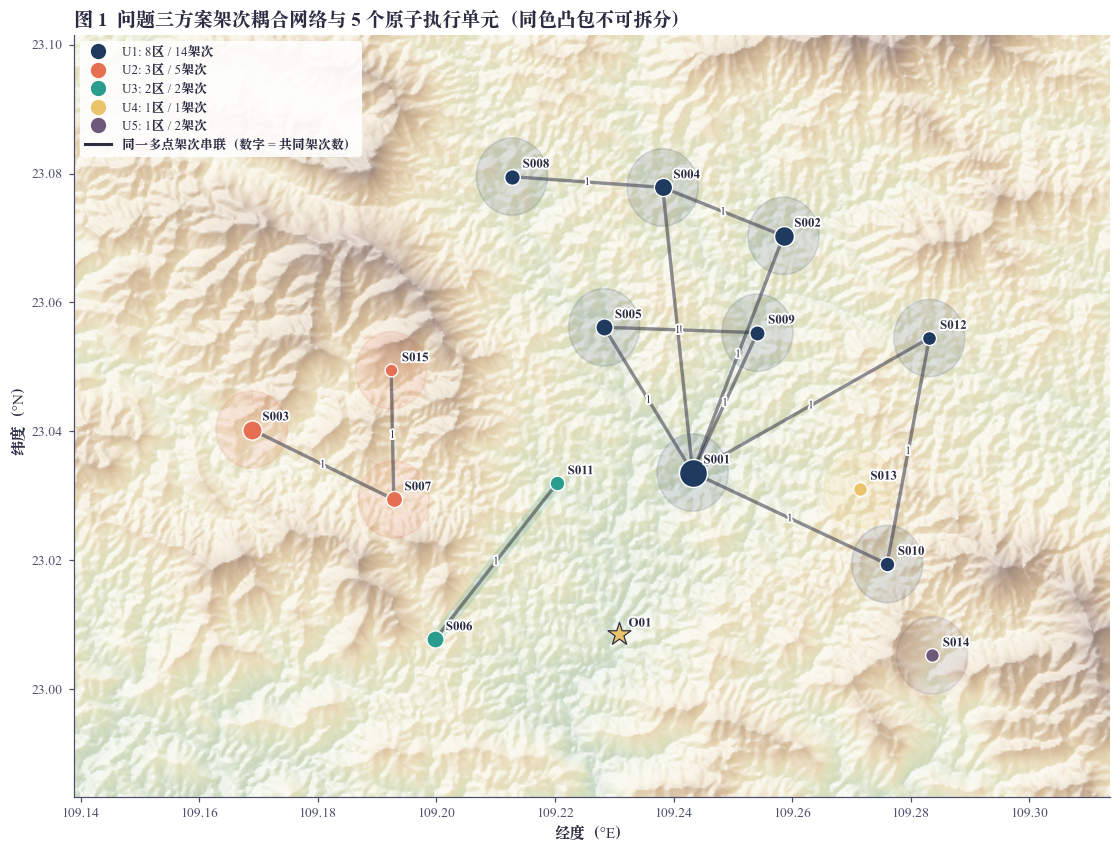

In [3]:
# 同架次服务区并查集与耦合网络
parent = {a: a for a in AREA_IDS}
edges = Counter()
def find(x):
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra
for ar in plan['areas']:
    for a in ar[1:]:
        union(ar[0], a)
    for a, b in itertools.combinations(ar, 2):
        edges[tuple(sorted((a, b)))] += 1
unit_map = defaultdict(list)
for a in AREA_IDS:
    unit_map[find(a)].append(a)
UNITS = sorted((tuple(v) for v in unit_map.values()), key=lambda u: (-len(u), u[0]))
U_ID = {a: i for i, u in enumerate(UNITS) for a in u}
unit_df = pd.DataFrame([
    dict(原子单元=f'U{i+1}', 服务区数=len(u), 服务区='、'.join(u),
         架次数=int(sum(set(ar).issubset(u) for ar in plan['areas'])),
         货箱数=int(box_df['服务区'].isin(u).sum()),
         质量_kg=float(box_df.loc[box_df['服务区'].isin(u), '质量_kg'].sum()),
         人口=int(areas.loc[list(u), 'pop'].sum()))
    for i, u in enumerate(UNITS)
])
assert sum(map(len, UNITS)) == len(AREA_IDS)
assert all(len({U_ID[a] for a in ar}) == 1 for ar in plan['areas'])
print(f'原子执行单元 {len(UNITS)} 个；多点架次 {int(plan["停靠点"].gt(1).sum())} 个')
display(unit_df)

# 局部地形底图。没有 DEM 时仍可用经纬度与村镇点位绘图。
HAS_DEM = False
try:
    m = sio.loadmat(find_file('镇龙乡及周边30米DEM.mat'))
    DEM = m['dem'].astype(np.float32)
    nodata = float(np.ravel(m['nodata'])[0])
    DEM[DEM == nodata] = np.nan
    tr = m['transform'].ravel()
    GEO = dict(dx=float(tr[0]), dy=float(-tr[4]), lon0=float(tr[2]), lat0=float(tr[5]))
    HAS_DEM = True
except (FileNotFoundError, KeyError, ValueError, OSError):
    DEM = None
    GEO = None
lon_min, lon_max = areas['lon'].min() - 0.03, areas['lon'].max() + 0.03
lat_min, lat_max = min(areas['lat'].min(), LAT_O) - 0.022, areas['lat'].max() + 0.022
ASPECT = 1 / math.cos(math.radians((lat_min + lat_max) / 2))

def base_map(ax, alpha=0.85):
    if HAS_DEM:
        nr, nc = DEM.shape
        lon_c = GEO['lon0'] + (np.arange(nc) + 0.5) * GEO['dx']
        lat_c = GEO['lat0'] - (np.arange(nr) + 0.5) * GEO['dy']
        cc = np.flatnonzero((lon_c >= lon_min) & (lon_c <= lon_max))
        rr = np.flatnonzero((lat_c <= lat_max) & (lat_c >= lat_min))
        if len(rr) and len(cc):
            r0, r1, c0, c1 = rr[0], rr[-1], cc[0], cc[-1]
            sub = DEM[r0:r1+1, c0:c1+1]
            extent = (GEO['lon0'] + c0*GEO['dx'], GEO['lon0'] + (c1+1)*GEO['dx'],
                      GEO['lat0'] - (r1+1)*GEO['dy'], GEO['lat0'] - r0*GEO['dy'])
            cmap_hypso = LinearSegmentedColormap.from_list(
                'hypso_q4', ['#D5E2D2', '#E8EBD3', '#F1E8CF', '#E5D3B8', '#D3BFA9', '#C2AFA3', '#B3A29B'])
            fill = np.nan_to_num(sub, nan=float(np.nanmin(sub)))
            rgb = LightSource(azdeg=315, altdeg=40).shade(
                fill, cmap=cmap_hypso, blend_mode='soft', vert_exag=1.0)
            ax.imshow(rgb, extent=extent, origin='upper', aspect=ASPECT,
                      interpolation='bilinear', alpha=alpha, zorder=0)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect(ASPECT)
    ax.grid(False)
    ax.scatter([LON_O], [LAT_O], s=250, marker='*', color=PAL['gold'],
               edgecolor=PAL['ink'], zorder=9)
    ax.annotate('O01', (LON_O, LAT_O), xytext=(6, 5), textcoords='offset points',
                fontsize=8.5, fontweight='bold', path_effects=HALO)

def hull_patch(ax, ids, color, pad=0.006, **kw):
    pts = areas.loc[list(ids), ['lon', 'lat']].to_numpy(float)
    if len(pts) >= 3:
        try:
            hull = ConvexHull(pts)
            poly = pts[hull.vertices]
            center = poly.mean(axis=0)
            poly = center + (poly - center) * 1.08
            ax.add_patch(Polygon(poly, closed=True, facecolor=color, alpha=0.13,
                                 edgecolor=color, lw=1.4, zorder=2, **kw))
        except Exception:
            for x, y in pts:
                ax.add_patch(plt.Circle((x, y), pad, facecolor=color, alpha=0.13,
                                        edgecolor=color, lw=1.2, zorder=2))
    elif len(pts) == 2:
        ax.plot(pts[:, 0], pts[:, 1], color=color, lw=8, alpha=0.16, zorder=2)
    elif len(pts) == 1:
        ax.add_patch(plt.Circle(tuple(pts[0]), pad, facecolor=color, alpha=0.13,
                                edgecolor=color, lw=1.4, zorder=2))

# 图 1：服务区节点、共同架次边和原子单元凸包
fig, ax = plt.subplots(figsize=(12.5, 9))
base_map(ax)
for k, u in enumerate(UNITS):
    hull_patch(ax, u, GROUP_COLOR[k % len(GROUP_COLOR)])
for (a, b), w in edges.items():
    xa, ya = areas.loc[a, ['lon', 'lat']]
    xb, yb = areas.loc[b, ['lon', 'lat']]
    ax.plot([xa, xb], [ya, yb], color=PAL['ink'], lw=0.8 + 1.4*w,
            alpha=0.52, zorder=3)
    ax.text((xa+xb)/2, (ya+yb)/2, str(w), fontsize=7.5, ha='center', va='center',
            color=PAL['ink'], path_effects=HALO, zorder=6)
for a in AREA_IDS:
    k = U_ID[a]
    r = areas.loc[a]
    ax.scatter(r['lon'], r['lat'], s=60 + 6*math.sqrt(r['pop']),
               color=GROUP_COLOR[k % len(GROUP_COLOR)], edgecolor='white', lw=0.9, zorder=7)
    ax.annotate(a, (r['lon'], r['lat']), xytext=(7, 6), textcoords='offset points',
                fontsize=8.5, fontweight='bold', path_effects=HALO, zorder=8)
handles = [Line2D([], [], marker='o', ls='none', color=GROUP_COLOR[k % len(GROUP_COLOR)],
                  markersize=9, label=f'U{k+1}: {len(u)}区 / {unit_df.iloc[k]["架次数"]}架次')
           for k, u in enumerate(UNITS)]
handles.append(Line2D([], [], color=PAL['ink'], lw=2, label='同一多点架次串联（数字 = 共同架次数）'))
ax.legend(handles=handles, loc='upper left', fontsize=8.5, frameon=True,
          framealpha=0.9, edgecolor='none')
ax.set_xlabel('经度（°E）')
ax.set_ylabel('纬度（°N）')
ax.set_title(f'图 1  问题三方案架次耦合网络与 {len(UNITS)} 个原子执行单元（同色凸包不可拆分）',
             loc='left', fontsize=12.5)
savefig(fig, '图01_架次耦合网络与原子单元')

## 8 分组资源核算函数（固定时序、区间图着色）

`group_eval(area_set)` 对一个任务组返回机型无人机和电池的并发峰值及峰值时刻、可核查的资源泳道、中继会话与能源组件需求、工作量指标。`JOINT` 记录所有架次联合执行时的峰值需求，作为分组冗余的基准。

In [4]:
def max_overlap(intervals):
    """半开区间的最大并发数及其峰值起始时刻。"""
    intervals = list(intervals)
    events = sorted([(float(a), 1) for a, b in intervals if b > a + 1e-9] +
                    [(float(b), -1) for a, b in intervals if b > a + 1e-9],
                    key=lambda x: (x[0], x[1]))
    cur = best = 0
    t_best = 0.0
    for t, delta in events:
        cur += delta
        if cur > best:
            best, t_best = cur, t
    return best, t_best

def lanes(intervals):
    # 区间图最少着色：按开始时刻分配最早空闲的泳道。
    free, assignment = [], {}
    for a, b, tag in sorted(intervals, key=lambda x: (x[0], x[1], str(x[2]))):
        lane = next((j for j, end in enumerate(free) if end <= a + 1e-9), None)
        if lane is None:
            free.append(b)
            lane = len(free) - 1
        else:
            free[lane] = b
        assignment[tag] = lane
    return assignment

def t_chg(soc, full):
    s = max(0., min(1., float(soc)))
    return full*(0.65*(0.9-s)/0.9 + 0.35) if s < 0.9 else full*0.35*(1-s)/0.1

def relay_energy(st, service_s):
    f = ST[st]
    return f['e_go'] + f['e_back'] + R['P_svc']*(R['t_link'] + service_s)/3600

def build_sessions(demand_frame):
    """按问题三规则合并各站需求窗，并在续航耗尽时以建链时段重叠接替。"""
    sessions = []
    for st, d in demand_frame.groupby('中继站'):
        f = ST[st]
        windows = sorted((float(v.开始_s), float(v.结束_s))
                         for v in d.itertuples(index=False))
        if not windows:
            continue
        gap_max = f['t_back'] + R['t_turn'] + R['t_prep'] + f['t_go'] + R['t_link']
        merged = [[windows[0][0], windows[0][1]]]
        for a, b in windows[1:]:
            if a <= merged[-1][1] + gap_max + 1e-9:
                merged[-1][1] = max(merged[-1][1], b)
            else:
                merged.append([a, b])
        for a, b in merged:
            cur = a
            while cur < b - 1e-9:
                end = min(b, cur + f['endur'])
                if end <= cur + 1e-9:
                    raise ValueError(f'{st} 单组件续航不足以完成建链交接')
                dep = cur - (R['t_prep'] + f['t_go'] + R['t_link'])
                if dep < -1e-7:
                    raise ValueError(f'{st} 会话无法在首个盲区窗前到达')
                dep = max(0., dep)
                ret = end + f['t_back']
                energy = relay_energy(st, end-cur)
                soc = 1 - energy/R['E_use']
                if energy > R['budget'] + 1e-7:
                    raise ValueError(f'{st} 会话超出返航能量预算')
                sessions.append(dict(station=st, t_dep=dep, t_linked=cur, t_leave=end,
                                     t_end=ret, E=energy, soc=soc))
                if end >= b - 1e-9:
                    break
                if f['endur'] <= R['t_link'] + 1e-9:
                    raise ValueError(f'{st} 单组件续航不足以完成建链交接')
                cur = end - R['t_link']  # 新机建链时旧机继续覆盖，需求窗不断链
    return sorted(sessions, key=lambda x: (x['t_dep'], x['station']))

from functools import lru_cache
@lru_cache(maxsize=None)
def group_eval(area_tuple):
    aset = set(area_tuple)
    sorties = plan[plan['areas'].apply(lambda ar: set(ar).issubset(aset))].copy()
    boxes = box_df[box_df['服务区'].isin(aset)]
    demand = dem_iv[dem_iv['架次'].isin(sorties['架次'])]
    sess = build_sessions(demand) if len(demand) else []
    res = dict(areas=tuple(sorted(aset)), sorties=sorties['架次'].tolist(),
               n_sorties=len(sorties), n_areas=len(aset), n_boxes=len(boxes),
               mass_kg=float(boxes['质量_kg'].sum()), pop=int(areas.loc[list(aset), 'pop'].sum()),
               work_s=float(sorties['持续_s'].sum()), E_T=float(sorties['能耗_kWh'].sum()),
               E_R=float(sum(v['E'] for v in sess)), sessions=sess)
    for g in TYPES:
        d = sorties[sorties['机型'] == g]
        res[('UAV', g)], res[('UAV', g, 'peak_t')] = max_overlap(zip(d['开始_s'], d['返仓_s']))
        res[('BAT', g)], res[('BAT', g, 'peak_t')] = max_overlap(zip(d['开始_s'], d['电池再可用_s']))
        res[('UAV', g, 'lanes')] = lanes([(v.开始_s, v.返仓_s, v.架次) for v in d.itertuples(index=False)])
        res[('BAT', g, 'lanes')] = lanes([(v.开始_s, v.电池再可用_s, v.架次) for v in d.itertuples(index=False)])
    res['RELAY'], res[('RELAY', 'peak_t')] = max_overlap(
        (v['t_dep'], v['t_end'] + R['t_turn']) for v in sess)
    res['COMP'], res[('COMP', 'peak_t')] = max_overlap(
        (v['t_dep'], v['t_end'] + t_chg(v['soc'], T_FULL_R)) for v in sess)
    res['relay_lanes'] = lanes([(v['t_dep'], v['t_end'] + R['t_turn'], i)
                                for i, v in enumerate(sess)])
    res['makespan'] = max([0.] + sorties['返仓_s'].tolist() + [v['t_end'] for v in sess])
    return res

JOINT = group_eval(tuple(AREA_IDS))
q3_actual = {
    **{('UAV', g): int(plan.loc[plan['机型'] == g, '无人机'].nunique()) for g in TYPES},
    **{('BAT', g): int(plan.loc[plan['机型'] == g, '电池'].nunique()) for g in TYPES},
    'RELAY': int(q3_sess['中继无人机'].nunique()),
    'COMP': int(q3_sess['组件'].nunique())
}
print('全部架次联合执行（固定时序）所需峰值资源：' + '、'.join(
    f'{RES_LABEL[k]} {JOINT[k]}' for k in RES_KEYS))
print('问题三实际投入：' + '、'.join(f'{RES_LABEL[k]} {q3_actual[k]}' for k in RES_KEYS))

全部架次联合执行（固定时序）所需峰值资源：运输机A 4、运输机B 2、运输机C 2、电池A 6、电池B 4、电池C 4、中继机 3、能源组件 3
问题三实际投入：运输机A 4、运输机B 2、运输机C 2、电池A 6、电池B 4、电池C 4、中继机 2、能源组件 4


## 9 分区枚举、指标计算与推荐分区

在原子单元层面精确枚举全部 2 组与 3 组划分，逐一核算资源需求。按“加权缺口 → 冗余 → 均衡偏差”的字典序选出推荐分区；图 2 将各划分画在“配置规模—均衡偏差”平面上，颜色表示加权缺口，点面积表示冗余，星标表示推荐方案。

K=2：精确枚举 15 种；推荐 ((0, 1, 3, 4), (2,))，加权缺口 10，冗余 3，β=0.430
K=3：精确枚举 25 种；推荐 ((0, 1, 4), (2,), (3,))，加权缺口 17，冗余 7，β=0.566
K=2 全部划分（按推荐字典序）：


,分区,配置规模,冗余,加权缺口,缺口件数,均衡偏差β,工作量份额,运输机A,运输机B,运输机C,电池A,电池B,电池C,中继机,能源组件
0,"{U1,U2,U4,U5} | {U3}",31,3,10,4,0.430,93%/7%,5,2,3,7,4,4,3,3
1,"{U1,U2,U3,U5} | {U4}",32,4,10,4,0.469,97%/3%,4,3,2,6,5,4,4,4
2,"{U1,U2,U3} | {U4,U5}",33,5,11,5,0.393,89%/11%,5,3,2,7,5,4,3,4
3,"{U1,U2,U3,U4} | {U5}",33,5,11,5,0.424,92%/8%,5,3,2,7,5,4,3,4
4,"{U1,U2,U5} | {U3,U4}",35,7,17,7,0.399,90%/10%,5,3,3,7,5,4,4,4
5,"{U1,U2} | {U3,U4,U5}",36,8,18,8,0.323,82%/18%,6,3,3,8,5,4,3,4
6,"{U1,U2,U4} | {U3,U5}",36,8,18,8,0.353,85%/15%,6,3,3,8,5,4,3,4
7,"{U1,U4} | {U2,U3,U5}",38,10,20,8,0.134,63%/37%,6,3,3,7,4,5,4,6
8,"{U1,U3,U4} | {U2,U5}",39,11,21,9,0.204,70%/30%,6,3,3,8,4,5,4,6
9,"{U1} | {U2,U3,U4,U5}",39,11,24,10,0.103,60%/40%,6,4,3,7,5,5,4,5


均衡优先方案： {U1} | {U2,U3,U4,U5}
K=3 全部划分（按推荐字典序）：


,分区,配置规模,冗余,加权缺口,缺口件数,均衡偏差β,工作量份额,运输机A,运输机B,运输机C,电池A,电池B,电池C,中继机,能源组件
0,"{U1,U2,U5} | {U3} | {U4}",35,7,17,7,0.566,90%/7%/3%,5,3,3,7,5,4,4,4
1,"{U1,U2} | {U3} | {U4,U5}",36,8,18,8,0.489,82%/7%/11%,6,3,3,8,5,4,3,4
2,"{U1,U2,U4} | {U3} | {U5}",36,8,18,8,0.520,85%/7%/8%,6,3,3,8,5,4,3,4
3,"{U1,U2,U3} | {U4} | {U5}",36,8,18,8,0.559,89%/3%/8%,5,4,2,7,6,4,4,4
4,"{U1,U2} | {U3,U4} | {U5}",39,11,25,11,0.489,82%/10%/8%,6,4,3,8,6,4,4,4
5,"{U1,U2} | {U3,U5} | {U4}",39,11,25,11,0.489,82%/15%/3%,6,4,3,8,6,4,4,4
6,"{U1,U4} | {U2,U5} | {U3}",41,13,27,11,0.300,63%/30%/7%,7,3,4,8,4,5,4,6
7,"{U1} | {U2,U3,U5} | {U4}",41,13,27,11,0.302,60%/37%/3%,6,4,3,7,5,5,5,6
8,"{U1,U3} | {U2,U5} | {U4}",42,14,28,12,0.340,67%/30%/3%,6,4,3,8,5,5,5,6
9,"{U1} | {U2,U4,U5} | {U3}",42,14,31,13,0.270,60%/33%/7%,7,4,4,8,5,5,4,5


均衡优先方案： {U1} | {U2,U4,U5} | {U3}


🖼️ 已保存 问题四/图02_分区枚举全景.png


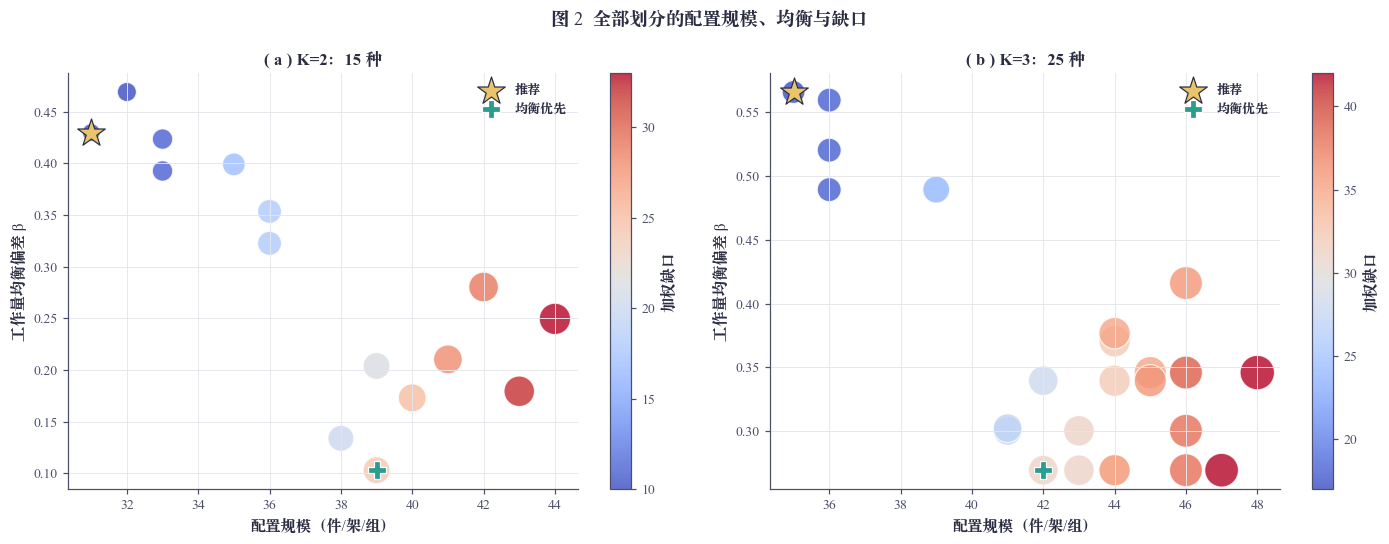

In [5]:
def set_partitions(items,K):
    n=len(items)
    def rec(i,groups):
        if i==n:
            if len(groups)==K:yield tuple(tuple(g) for g in groups)
            return
        if len(groups)+(n-i)<K:return
        for g in groups:
            g.append(items[i]);yield from rec(i+1,groups);g.pop()
        if len(groups)<K:
            groups.append([items[i]]);yield from rec(i+1,groups);groups.pop()
    yield from rec(0,[])
W_GAP={**{('UAV',g):3 for g in TYPES},**{('BAT',g):1 for g in TYPES},'RELAY':3,'COMP':1}
def partition_eval(parts):
    groups=[group_eval(tuple(sorted(a for u in part for a in UNITS[u]))) for part in parts]
    total={k:sum(r[k] for r in groups) for k in RES_KEYS}
    gap={k:max(0,total[k]-INV[k]) for k in RES_KEYS}
    red={k:total[k]-JOINT[k] for k in RES_KEYS}
    works=np.array([r['work_s'] for r in groups]);shares=works/works.sum()
    beta=float(np.max(np.abs(shares-1/len(groups))))
    w_gap=sum(W_GAP[k]*gap[k] for k in RES_KEYS)
    scale=sum(total.values());red_total=sum(red.values())
    return dict(groups=groups,parts=parts,total=total,gap=gap,red=red,shares=shares,beta=beta,
                w_gap=w_gap,n_gap=sum(gap.values()),scale=scale,red_total=red_total,
                key=(w_gap,red_total,beta,scale))
PART={}
for K in (2,3):
    rows=[partition_eval(p) for p in set_partitions(tuple(range(len(UNITS))),K)]
    rows.sort(key=lambda e:(e['key'],e['parts']));PART[K]=rows
    print(f'K={K}：精确枚举 {len(rows)} 种；推荐 {rows[0]["parts"]}，加权缺口 {rows[0]["w_gap"]}，冗余 {rows[0]["red_total"]}，β={rows[0]["beta"]:.3f}')
assert len(PART[2])==2**(len(UNITS)-1)-1
BEST={K:PART[K][0] for K in (2,3)}
BAL={K:min(PART[K],key=lambda e:(e['beta'],e['w_gap'],e['red_total'],e['scale'])) for K in (2,3)}
def pname(e):return ' | '.join('{'+','.join(f'U{i+1}' for i in part)+'}' for part in e['parts'])
def rank_table(rows):
    return pd.DataFrame([{'分区':pname(e),'配置规模':e['scale'],'冗余':e['red_total'],'加权缺口':e['w_gap'],
                          '缺口件数':e['n_gap'],'均衡偏差β':round(e['beta'],3),
                          '工作量份额':'/'.join(f'{s:.0%}' for s in e['shares']),
                          **{RES_LABEL[k]:e['total'][k] for k in RES_KEYS}} for e in rows])
for K in (2,3):
    print(f'K={K} 全部划分（按推荐字典序）：');display(rank_table(PART[K]))
    print('均衡优先方案：',pname(BAL[K]))

# 图 2：所有可行分区在配置规模—均衡平面的分布
fig,axs=plt.subplots(1,2,figsize=(13,5))
for ax,K in zip(axs,(2,3)):
    rows=PART[K];xx=[e['scale'] for e in rows];yy=[e['beta'] for e in rows]
    col=[e['w_gap'] for e in rows];size=[70+22*e['red_total'] for e in rows]
    sc=ax.scatter(xx,yy,c=col,s=size,cmap='coolwarm',edgecolors='white',alpha=.8)
    ax.scatter([BEST[K]['scale']],[BEST[K]['beta']],marker='*',s=360,c=PAL['gold'],edgecolors=PAL['ink'],zorder=5,label='推荐')
    ax.scatter([BAL[K]['scale']],[BAL[K]['beta']],marker='P',s=150,c=PAL['teal'],edgecolors='white',zorder=5,label='均衡优先')
    ax.set_title(f'( {"ab"[K-2]} ) K={K}：{len(rows)} 种');ax.set_xlabel('配置规模（件/架/组）');ax.set_ylabel('工作量均衡偏差 β')
    ax.legend(loc='best');fig.colorbar(sc,ax=ax,label='加权缺口')
fig.suptitle('图 2  全部划分的配置规模、均衡与缺口');fig.tight_layout();savefig(fig,'图02_分区枚举全景')

## 10 推荐分区的资源配置方案与图 3、图 4

分别列出推荐方案 A（缺口优先）与均衡方案 B。图 3 为四种候选方案的分区地图，展示组色区域、组内航线与各组使用的中继站；图 4 为资源天平图，按资源类型堆叠各组需求，以竖线标出库存，并用红色边框标注超出部分。

K=2 方案A（缺口最小、推荐）：{U1,U2,U4,U5} | {U3}


,原子单元,服务区,服务区数,架次,货箱,人口,质量_kg,运输能耗_kWh,中继能耗_kWh,中继会话,完成_h,运输机A,运输机B,运输机C,电池A,电池B,电池C,中继机,能源组件
任务组,,,,,,,,,,,,,,,,,,,
G1,"U1,U2,U4,U5",S001、S002、S003、S004、S005、S007、S008、S009、S010、S...,13.0,22.0,71.0,3271.0,674.0,71.23,4.97,4.0,2.82,4,2,2,6,4,3,3,3
G2,U3,S006、S011,2.0,2.0,9.0,151.0,84.0,5.18,0.00,0.0,1.42,1,0,1,1,0,1,0,0
合计,NaN,NaN,15.0,24.0,80.0,3422.0,758.0,76.40,4.97,4.0,NaN,5,2,3,7,4,4,3,3
库存,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2,6,4,4,2,6
缺口,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,1,0,0,1,0
联合执行需求,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2,6,4,4,3,3
冗余（组间隔离）,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,1,0,0,0,0


K=2 方案B（均衡优先）：{U1} | {U2,U3,U4,U5}


,原子单元,服务区,服务区数,架次,货箱,人口,质量_kg,运输能耗_kWh,中继能耗_kWh,中继会话,完成_h,运输机A,运输机B,运输机C,电池A,电池B,电池C,中继机,能源组件
任务组,,,,,,,,,,,,,,,,,,,
G1,U1,S001、S002、S004、S005、S008、S009、S010、S012,8.0,14.0,49.0,2891.0,473.0,49.15,4.18,3.0,2.43,3,2,2,4,3,3,2,2
G2,"U2,U3,U4,U5",S003、S006、S007、S011、S013、S014、S015,7.0,10.0,31.0,531.0,285.0,27.25,3.52,5.0,2.82,3,2,1,3,2,2,2,3
合计,NaN,NaN,15.0,24.0,80.0,3422.0,758.0,76.40,7.69,8.0,NaN,6,4,3,7,5,5,4,5
库存,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2,6,4,4,2,6
缺口,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,1,1,1,2,0
联合执行需求,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2,6,4,4,3,3
冗余（组间隔离）,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,1,1,1,1,1,2


K=3 方案A（缺口最小、推荐）：{U1,U2,U5} | {U3} | {U4}


,原子单元,服务区,服务区数,架次,货箱,人口,质量_kg,运输能耗_kWh,中继能耗_kWh,中继会话,完成_h,运输机A,运输机B,运输机C,电池A,电池B,电池C,中继机,能源组件
任务组,,,,,,,,,,,,,,,,,,,
G1,"U1,U2,U5",S001、S002、S003、S004、S005、S007、S008、S009、S010、S...,12.0,21.0,68.0,3257.0,649.0,69.40,4.64,4.0,2.82,4,2,2,6,4,3,3,3
G2,U3,S006、S011,2.0,2.0,9.0,151.0,84.0,5.18,0.00,0.0,1.42,1,0,1,1,0,1,0,0
G3,U4,S013,1.0,1.0,3.0,14.0,25.0,1.82,0.42,1.0,1.17,0,1,0,0,1,0,1,1
合计,NaN,NaN,15.0,24.0,80.0,3422.0,758.0,76.40,5.06,5.0,NaN,5,3,3,7,5,4,4,4
库存,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2,6,4,4,2,6
缺口,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1,0,2,0
联合执行需求,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2,6,4,4,3,3
冗余（组间隔离）,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1,0,1,1


K=3 方案B（均衡优先）：{U1} | {U2,U4,U5} | {U3}


,原子单元,服务区,服务区数,架次,货箱,人口,质量_kg,运输能耗_kWh,中继能耗_kWh,中继会话,完成_h,运输机A,运输机B,运输机C,电池A,电池B,电池C,中继机,能源组件
任务组,,,,,,,,,,,,,,,,,,,
G1,U1,S001、S002、S004、S005、S008、S009、S010、S012,8.0,14.0,49.0,2891.0,473.0,49.15,4.18,3.0,2.43,3,2,2,4,3,3,2,2
G2,"U2,U4,U5",S003、S007、S013、S014、S015,5.0,8.0,22.0,380.0,201.0,22.07,3.52,5.0,2.82,3,2,1,3,2,1,2,3
G3,U3,S006、S011,2.0,2.0,9.0,151.0,84.0,5.18,0.00,0.0,1.42,1,0,1,1,0,1,0,0
合计,NaN,NaN,15.0,24.0,80.0,3422.0,758.0,76.40,7.69,8.0,NaN,7,4,4,8,5,5,4,5
库存,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2,6,4,4,2,6
缺口,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,2,2,1,1,2,0
联合执行需求,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2,6,4,4,3,3
冗余（组间隔离）,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,2,2,1,1,1,2


🖼️ 已保存 问题四/图03_推荐分区地图.png


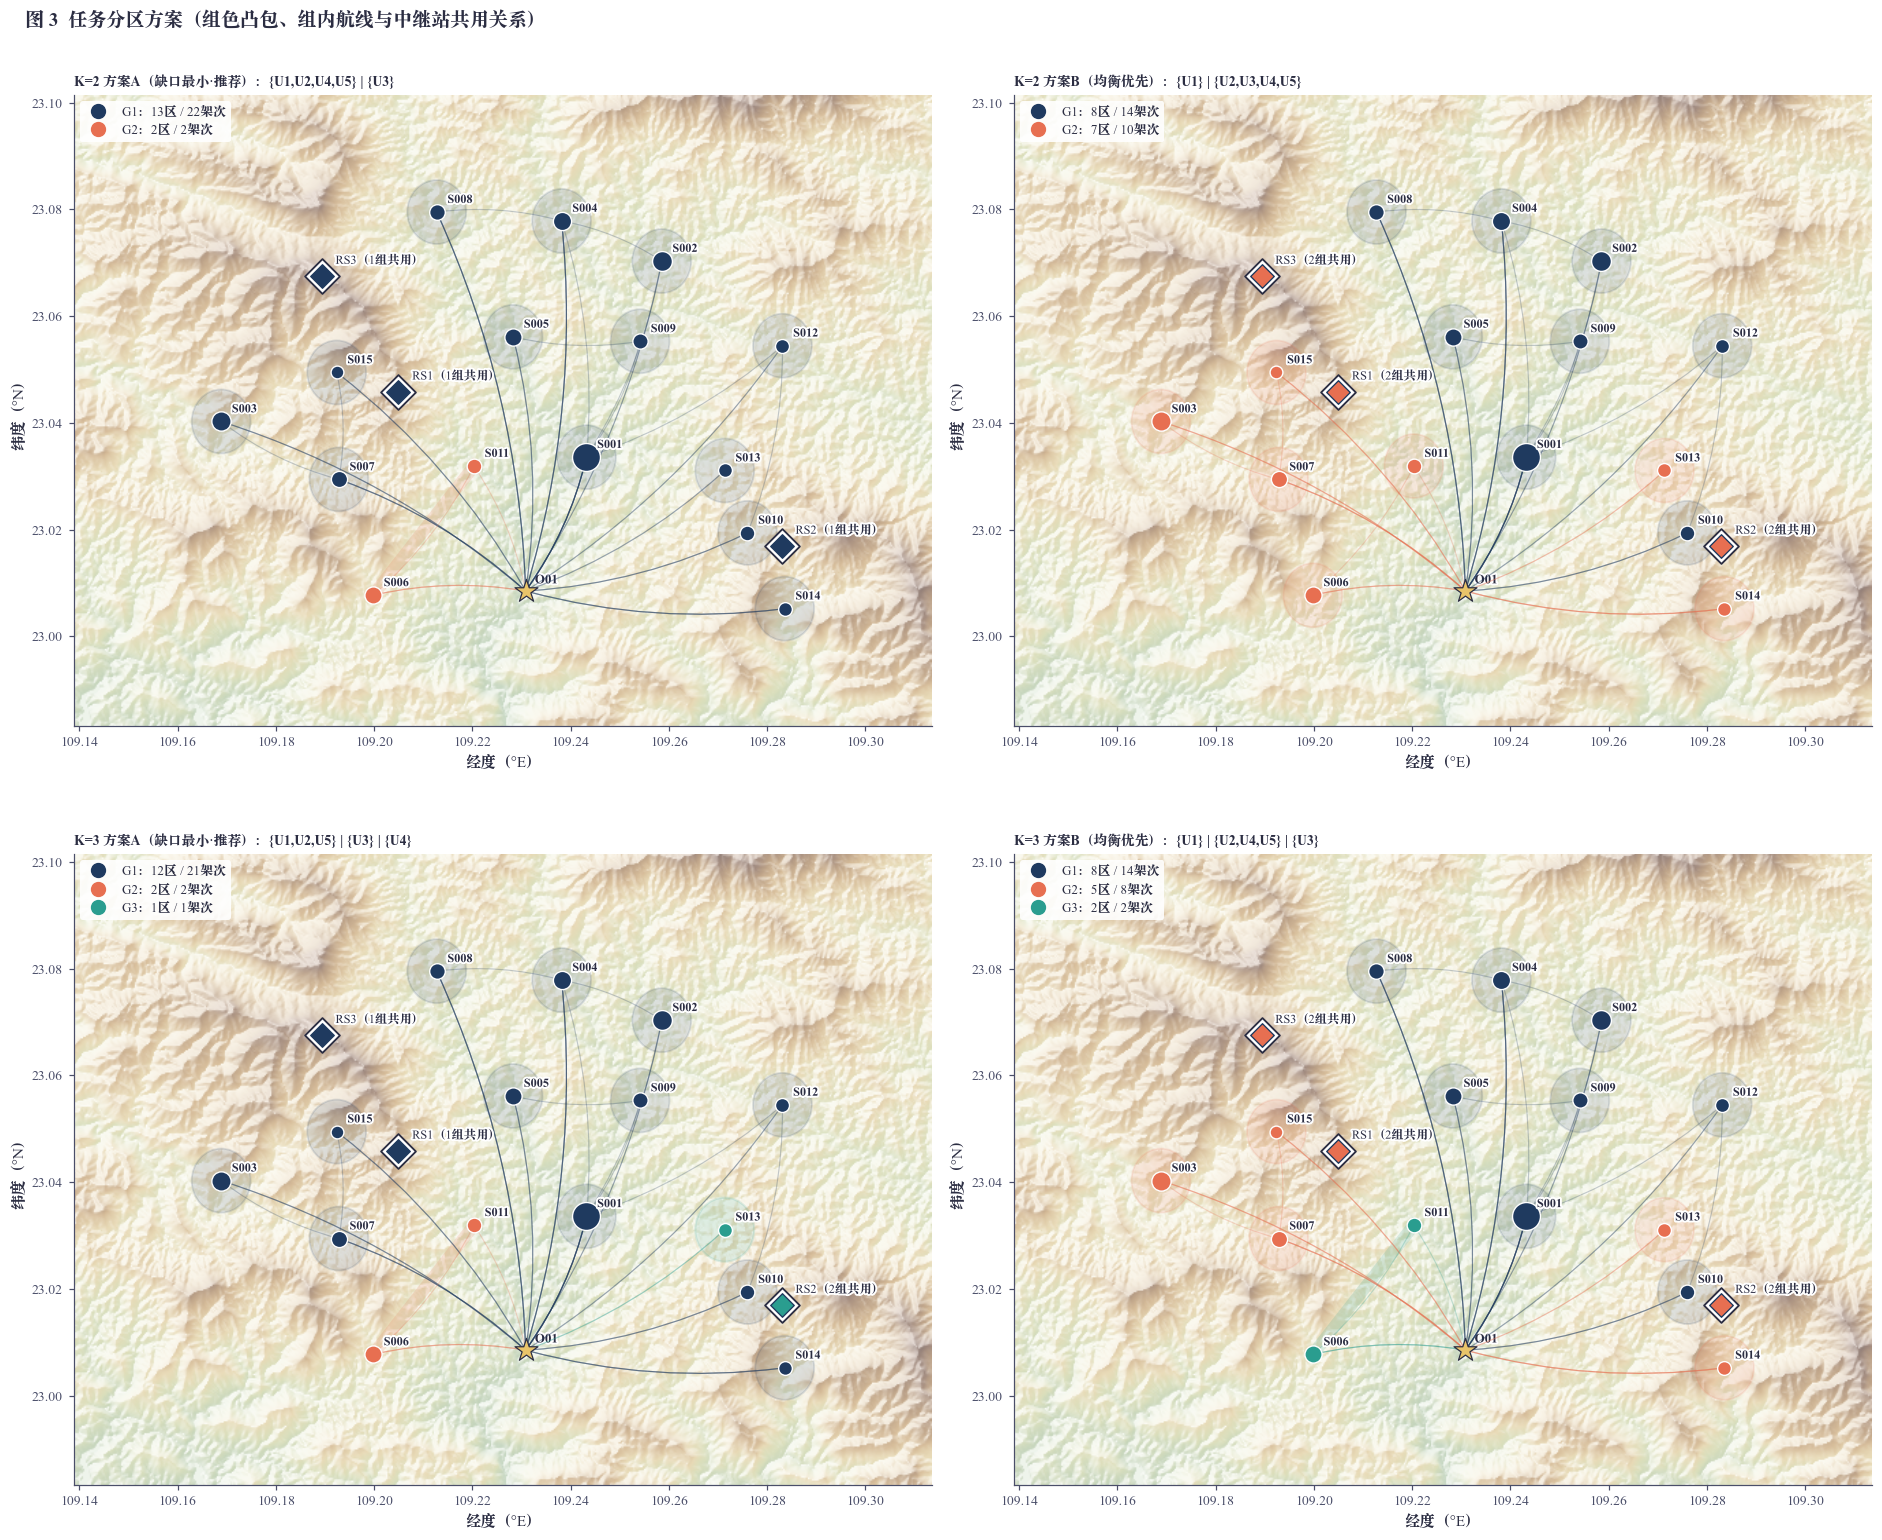

In [6]:
def config_table(K, e):
    rows = []
    for gi, r in enumerate(e['groups']):
        rows.append(dict(任务组=f'G{gi+1}', 原子单元=','.join(f'U{u+1}' for u in e['parts'][gi]),
                         服务区='、'.join(r['areas']), 服务区数=r['n_areas'], 架次=r['n_sorties'],
                         货箱=r['n_boxes'], 人口=r['pop'], 质量_kg=r['mass_kg'],
                         运输能耗_kWh=r['E_T'], 中继能耗_kWh=r['E_R'],
                         中继会话=len(r['sessions']), 完成_h=r['makespan']/3600,
                         **{RES_LABEL[k]: r[k] for k in RES_KEYS}))
    rows.append(dict(任务组='合计', 服务区数=len(AREA_IDS),
                     架次=sum(r['n_sorties'] for r in e['groups']),
                     货箱=sum(r['n_boxes'] for r in e['groups']),
                     人口=sum(r['pop'] for r in e['groups']),
                     质量_kg=sum(r['mass_kg'] for r in e['groups']),
                     运输能耗_kWh=sum(r['E_T'] for r in e['groups']),
                     中继能耗_kWh=sum(r['E_R'] for r in e['groups']),
                     中继会话=sum(len(r['sessions']) for r in e['groups']),
                     **{RES_LABEL[k]: e['total'][k] for k in RES_KEYS}))
    for name, values in [('库存', INV), ('缺口', e['gap']), ('联合执行需求', JOINT), ('冗余（组间隔离）', e['red'])]:
        rows.append(dict(任务组=name, **{RES_LABEL[k]: values[k] for k in RES_KEYS}))
    return pd.DataFrame(rows).set_index('任务组')

CFG = {}
for K in (2, 3):
    for tag, e in [('A', BEST[K]), ('B', BAL[K])]:
        CFG[K, tag] = config_table(K, e)
        print(f'K={K} 方案{tag}（{"缺口最小、推荐" if tag == "A" else "均衡优先"}）：{pname(e)}')
        display(CFG[K, tag].round(2))

# 图 3：两种组数下的缺口优先方案 A 与均衡方案 B。
fig, axes = plt.subplots(2, 2, figsize=(17, 14), constrained_layout=True)
for ax, (K, tag) in zip(axes.ravel(), [(2, 'A'), (2, 'B'), (3, 'A'), (3, 'B')]):
    e = BEST[K] if tag == 'A' else BAL[K]
    base_map(ax)
    for gi, r in enumerate(e['groups']):
        col = GROUP_COLOR[gi]
        hull_patch(ax, r['areas'], col)
        for pid in r['sorties']:
            ar = plan.loc[plan['架次'] == pid, 'areas'].iloc[0]
            nodes = [('O01', LON_O, LAT_O)] + [
                (a, float(areas.loc[a, 'lon']), float(areas.loc[a, 'lat'])) for a in ar] + [('O01', LON_O, LAT_O)]
            for (n1, x1, y1), (n2, x2, y2) in zip(nodes[:-1], nodes[1:]):
                rad = 0.10 if n1 < n2 else -0.10
                ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                            arrowprops=dict(arrowstyle='-', connectionstyle=f'arc3,rad={rad}',
                                            color=col, lw=0.75, alpha=0.25), zorder=3)
        for a in r['areas']:
            xy = areas.loc[a]
            ax.scatter(xy['lon'], xy['lat'], s=60+6*math.sqrt(xy['pop']), color=col,
                       edgecolor='white', lw=0.9, zorder=6)
            ax.annotate(a, (xy['lon'], xy['lat']), xytext=(7, 6), textcoords='offset points',
                        fontsize=8, fontweight='bold', path_effects=HALO, zorder=7)
    # 中继站以参与该站会话的任务组着色，叠色表示组间共用站点。
    for st in ST_NAMES:
        users = [gi for gi, r in enumerate(e['groups'])
                 if any(x['station'] == st for x in r['sessions'])]
        ax.scatter(ST[st]['lon'], ST[st]['lat'], s=260, marker='D', color='white',
                   edgecolor=PAL['ink'], lw=1.2, zorder=9)
        for j, gi in enumerate(users):
            ax.scatter(ST[st]['lon'], ST[st]['lat'], s=120-35*j, marker='D',
                       color=GROUP_COLOR[gi], zorder=10+j)
        ax.annotate(f'{st}（{len(users)}组共用）', (ST[st]['lon'], ST[st]['lat']),
                    xytext=(9, 8), textcoords='offset points', fontsize=8,
                    path_effects=HALO, zorder=11)
    handles = [Line2D([], [], marker='o', ls='none', color=GROUP_COLOR[gi], markersize=9,
                      label=f'G{gi+1}：{r["n_areas"]}区 / {r["n_sorties"]}架次')
               for gi, r in enumerate(e['groups'])]
    ax.legend(handles=handles, loc='upper left', fontsize=8.5, frameon=True,
              framealpha=0.9, edgecolor='none')
    ax.set_xlabel('经度（°E）')
    ax.set_ylabel('纬度（°N）')
    ax.set_title(f'K={K} 方案{tag}（{"缺口最小·推荐" if tag == "A" else "均衡优先"}）：{pname(e)}',
                 loc='left', fontsize=9)
fig.suptitle('图 3  任务分区方案（组色凸包、组内航线与中继站共用关系）',
             x=0.01, ha='left', fontsize=12.5, fontweight='bold')
savefig(fig, '图03_推荐分区地图')

🖼️ 已保存 问题四/图04_资源天平图.png


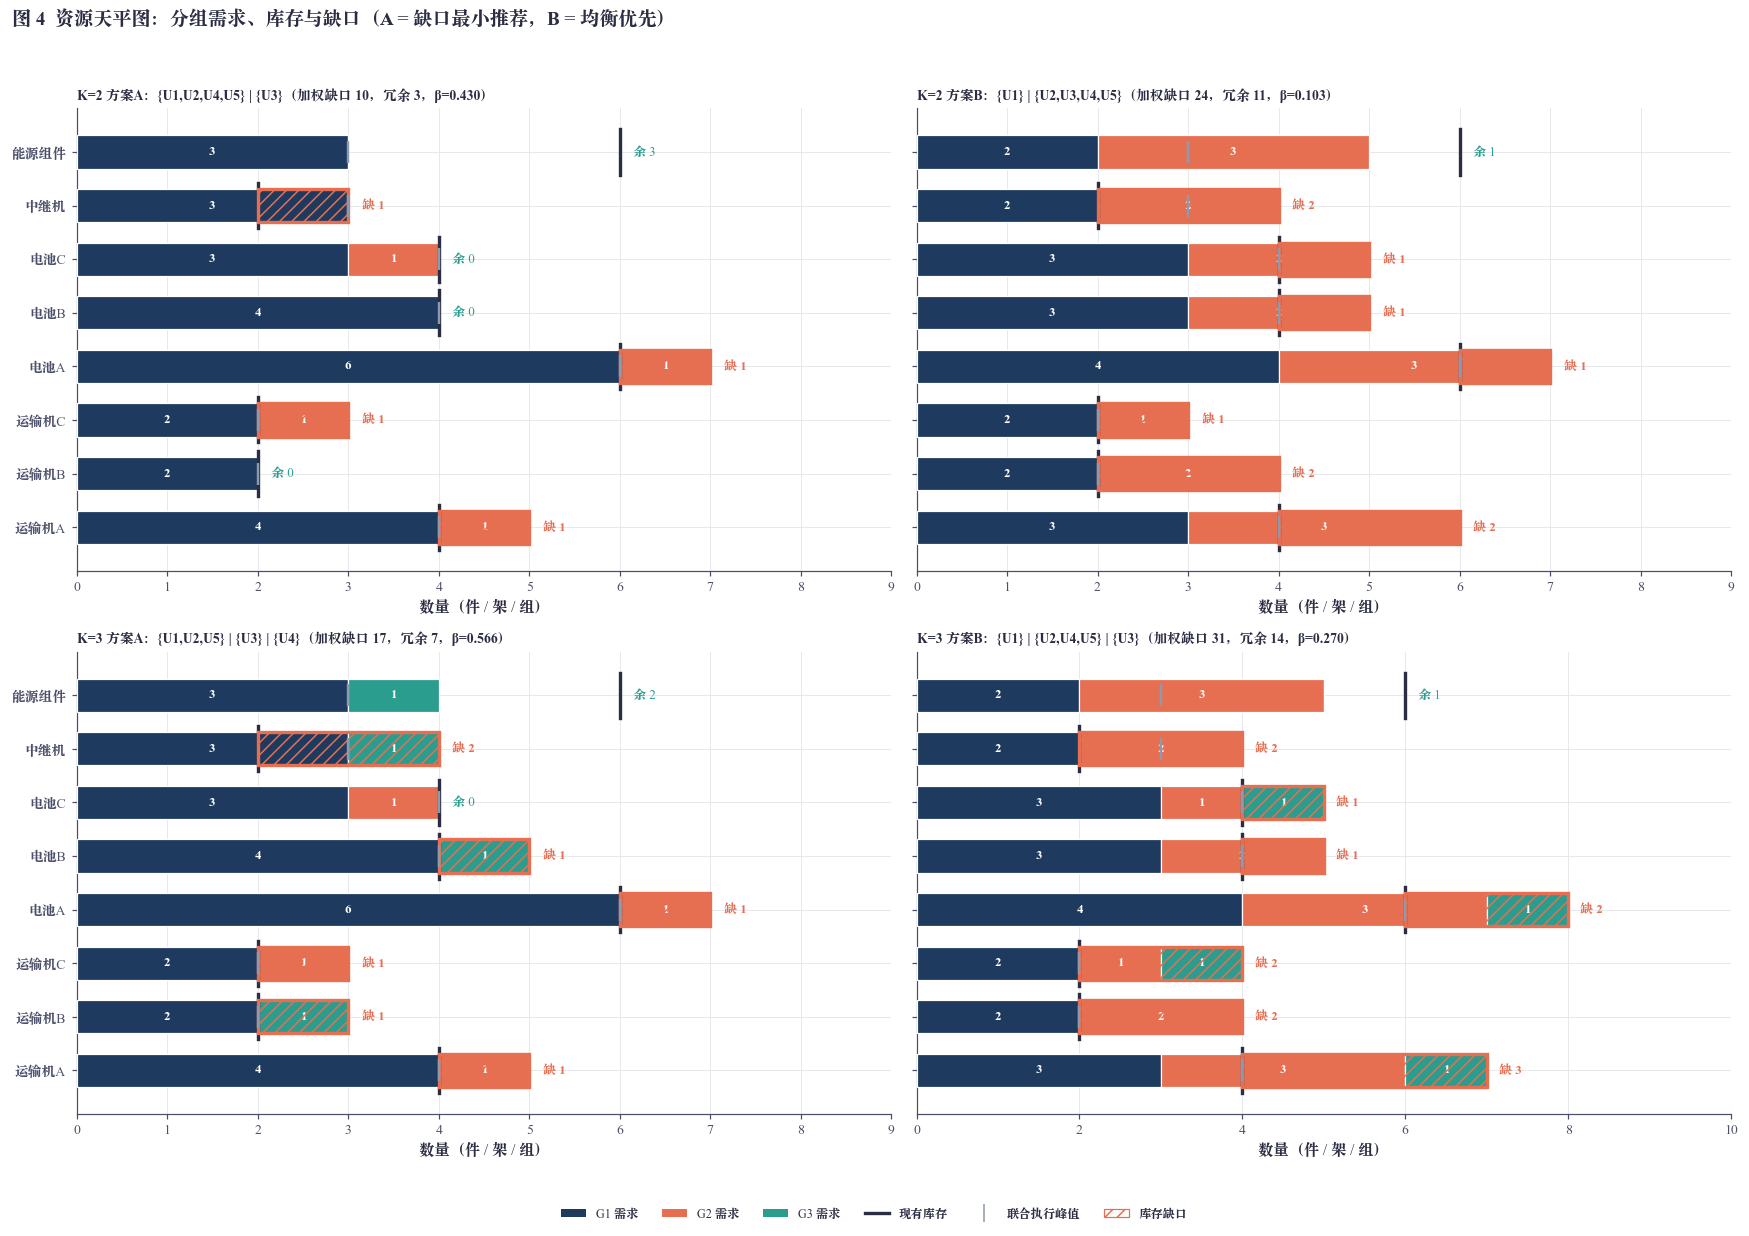

In [7]:
# 图 4：各组需求堆叠、库存线、联合执行峰值与分区缺口
fig, axes = plt.subplots(2, 2, figsize=(16, 11.5), sharey=True, constrained_layout=True)
for ax, (K, tag) in zip(axes.ravel(), [(2, 'A'), (2, 'B'), (3, 'A'), (3, 'B')]):
    e = BEST[K] if tag == 'A' else BAL[K]
    y = np.arange(len(RES_KEYS))
    left = np.zeros(len(RES_KEYS), dtype=float)
    for gi, r in enumerate(e['groups']):
        vals = np.array([r[k] for k in RES_KEYS], dtype=float)
        ax.barh(y, vals, left=left, color=GROUP_COLOR[gi], edgecolor='white', lw=0.8,
                height=0.62, label=f'G{gi+1} 需求', zorder=3)
        for yi, (x0, value) in enumerate(zip(left, vals)):
            if value > 0:
                ax.text(x0+value/2, yi, f'{int(value)}', ha='center', va='center',
                        fontsize=8.5, color='white', fontweight='bold', zorder=5)
        left += vals
    inv = np.array([INV[k] for k in RES_KEYS], dtype=float)
    joint = np.array([JOINT[k] for k in RES_KEYS], dtype=float)
    for yi in range(len(RES_KEYS)):
        ax.plot([inv[yi], inv[yi]], [yi-0.42, yi+0.42], color=PAL['ink'], lw=2.2, zorder=6)
        ax.scatter(joint[yi], yi, marker='|', s=200, color=PAL['grey'], zorder=7)
        if left[yi] > inv[yi]:
            ax.add_patch(Rectangle((inv[yi], yi-0.31), left[yi]-inv[yi], 0.62,
                                   facecolor='none', edgecolor=PAL['coral'], lw=2.2,
                                   hatch='///', zorder=6))
            ax.text(left[yi]+0.15, yi, f'缺 {int(left[yi]-inv[yi])}', va='center',
                    fontsize=8.5, color=PAL['coral'], fontweight='bold')
        else:
            ax.text(max(left[yi], inv[yi])+0.15, yi, f'余 {int(inv[yi]-left[yi])}',
                    va='center', fontsize=8.5, color=PAL['teal'])
    ax.set_yticks(y, [RES_LABEL[k] for k in RES_KEYS])
    ax.invert_yaxis()
    ax.set_xlim(0, max(left.max(), inv.max())+2)
    ax.set_xlabel('数量（件 / 架 / 组）')
    ax.set_title(f'K={K} 方案{tag}：{pname(e)}（加权缺口 {e["w_gap"]}，冗余 {e["red_total"]}，β={e["beta"]:.3f}）',
                 loc='left', fontsize=9)
fig_handles = [Patch(facecolor=GROUP_COLOR[i], label=f'G{i+1} 需求') for i in range(3)]
fig_handles += [Line2D([], [], color=PAL['ink'], lw=2.2, label='现有库存'),
                Line2D([], [], color=PAL['grey'], marker='|', ls='none', markersize=12, label='联合执行峰值'),
                Rectangle((0, 0), 1, 1, facecolor='none', edgecolor=PAL['coral'], hatch='///', label='库存缺口')]
fig.legend(handles=fig_handles, loc='lower center', bbox_to_anchor=(0.5, 0.015),
           ncol=6, fontsize=8, frameon=False)
fig.suptitle('图 4  资源天平图：分组需求、库存与缺口（A = 缺口最小推荐，B = 均衡优先）',
             x=0.01, ha='left', fontsize=12.5, fontweight='bold')
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
savefig(fig, '图04_资源天平图')

## 11 图 5、图 6：分组资源占用时序与独立执行甘特图

图 5 对 $K=3$ 推荐分区逐组绘制运输机在用数（按机型堆叠）和电池占用数（任务加充电），标出各机型峰值时刻及库存参照；峰值对应每组独立执行所需配置，不同组的设备不能跨组调配。图 6 将运输架次与中继会话排入最少资源泳道，显示准备、运输、建链、在站服务和返程时段。

🖼️ 已保存 问题四/图05_分组资源占用时序.png


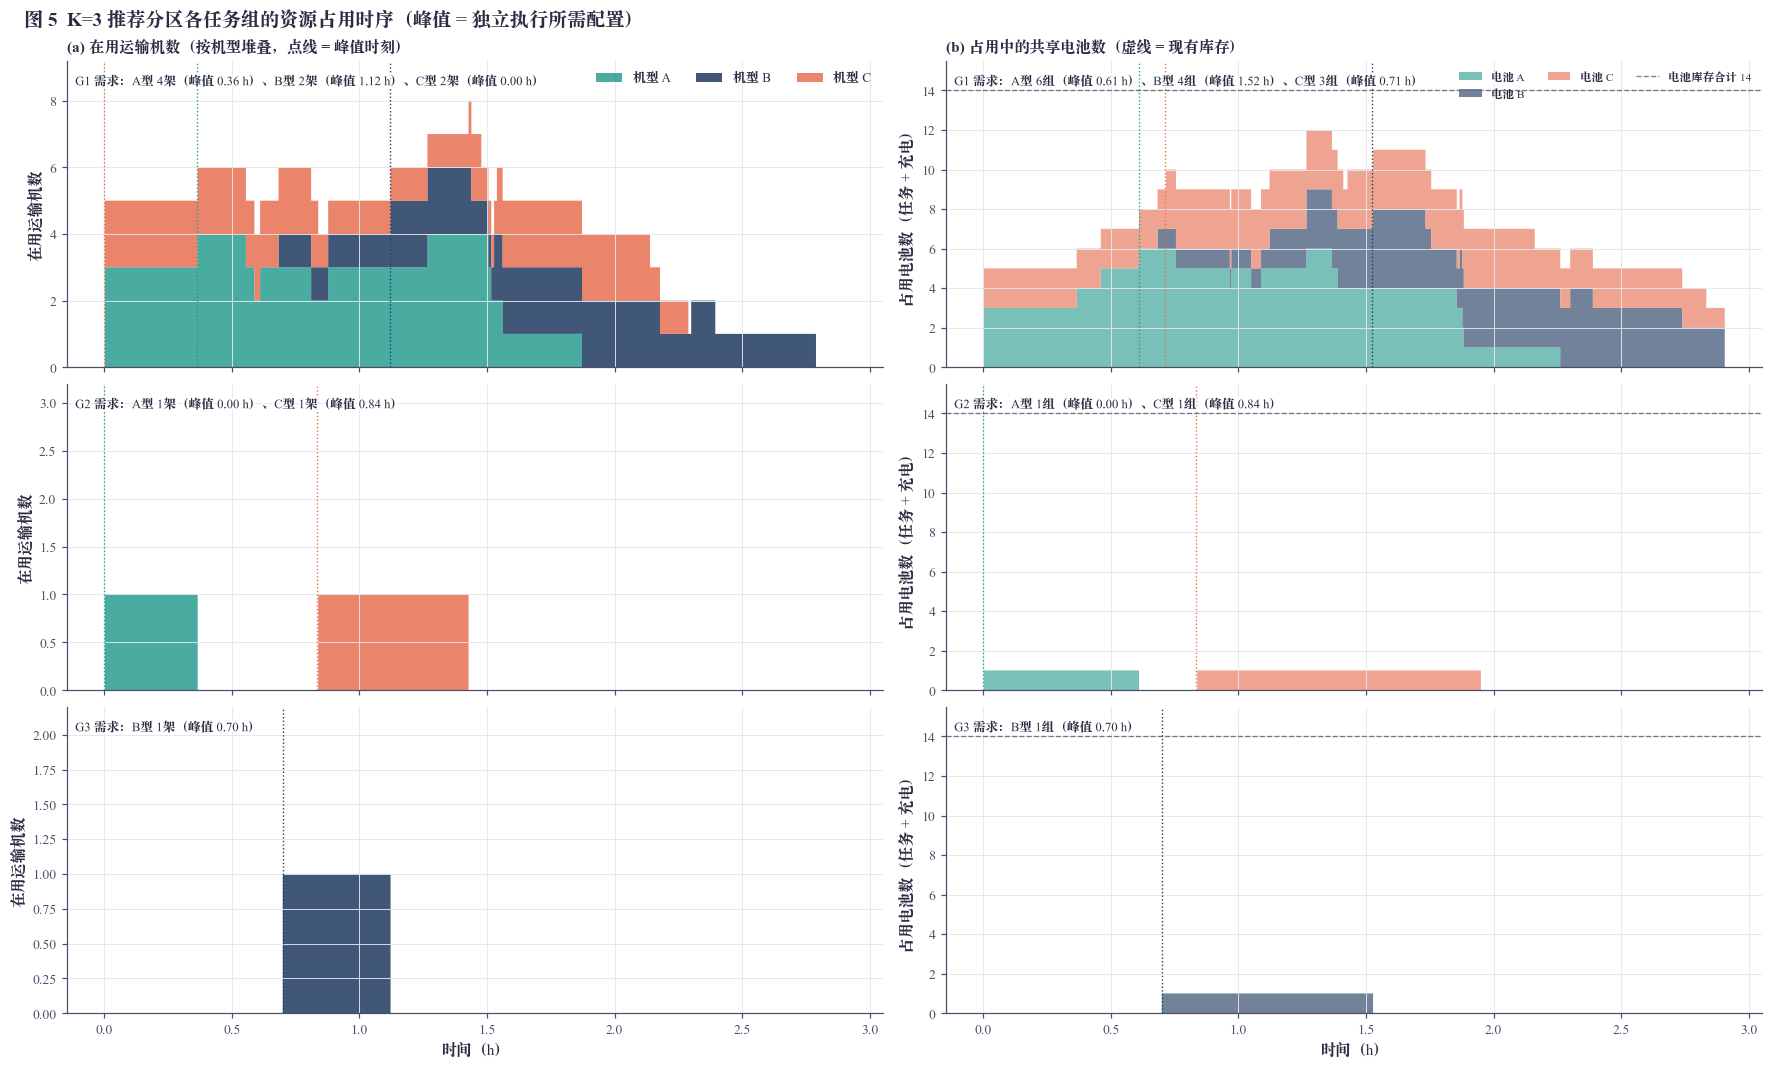

In [8]:
def occupancy(intervals, t):
    out = np.zeros(len(t), dtype=int)
    for a, b in intervals:
        out += ((t >= float(a)) & (t < float(b))).astype(int)
    return out

# 图 5：K=3 推荐方案中运输无人机与共享电池的占用时序
K_SHOW = 3
e = BEST[K_SHOW]
T_END = max(r['makespan'] for r in e['groups']) + 300
t = np.arange(0, T_END+20, 20.0)
fig, axes = plt.subplots(len(e['groups']), 2, figsize=(16, 3.2*len(e['groups'])),
                         sharex=True, constrained_layout=True)
axes = np.atleast_2d(axes)
for gi, r in enumerate(e['groups']):
    d = plan[plan['架次'].isin(r['sorties'])]
    # 左：在用运输机数，按机型堆叠；点线标出各机型资源峰值。
    ax = axes[gi, 0]
    use = []
    for g in TYPES:
        q = d[d['机型'] == g]
        use.append(occupancy(zip(q['开始_s'], q['返仓_s']), t))
    ax.stackplot(t/3600, use, step='post', colors=[TYPE_COLOR[g] for g in TYPES],
                 labels=[f'机型 {g}' for g in TYPES], alpha=0.85)
    for g in TYPES:
        if r[('UAV', g)] > 0:
            ax.axvline(r[('UAV', g, 'peak_t')]/3600, color=TYPE_COLOR[g], lw=0.9, ls=':')
    peak_text = '、'.join(f'{g}型 {r[("UAV", g)]}架（峰值 {r[("UAV", g, "peak_t")]/3600:.2f} h）'
                         for g in TYPES if r[('UAV', g)] > 0)
    ax.text(0.01, 0.95, f'G{gi+1} 需求：{peak_text}', transform=ax.transAxes,
            va='top', fontsize=8.3, path_effects=HALO)
    ax.set_ylabel('在用运输机数')
    ax.set_ylim(0, max(1, sum(r[('UAV', g)] for g in TYPES))+1.2)
    if gi == 0:
        ax.set_title('(a) 在用运输机数（按机型堆叠，点线 = 峰值时刻）', loc='left', fontsize=10)
        ax.legend(loc='upper right', ncol=3)
    # 右：任务期间加充电期间的电池占用数。
    ax = axes[gi, 1]
    occupied = []
    for g in TYPES:
        q = d[d['机型'] == g]
        occupied.append(occupancy(zip(q['开始_s'], q['电池再可用_s']), t))
    ax.stackplot(t/3600, occupied, step='post',
                 colors=[shade(TYPE_COLOR[g], 0.3) for g in TYPES],
                 labels=[f'电池 {g}' for g in TYPES], alpha=0.9)
    for g in TYPES:
        if r[('BAT', g)] > 0:
            ax.axvline(r[('BAT', g, 'peak_t')]/3600, color=TYPE_COLOR[g], lw=0.9, ls=':')
    peak_text = '、'.join(f'{g}型 {r[("BAT", g)]}组（峰值 {r[("BAT", g, "peak_t")]/3600:.2f} h）'
                         for g in TYPES if r[('BAT', g)] > 0)
    stock = sum(INV[('BAT', g)] for g in TYPES)
    ax.axhline(stock, color=PAL['ink'], lw=0.9, ls='--', alpha=0.6, label=f'电池库存合计 {stock}')
    ax.text(0.01, 0.95, f'G{gi+1} 需求：{peak_text}', transform=ax.transAxes,
            va='top', fontsize=8.3, path_effects=HALO)
    ax.set_ylabel('占用电池数（任务 + 充电）')
    ax.set_ylim(0, max(1, sum(r[('BAT', g)] for g in TYPES), stock)+1.5)
    if gi == 0:
        ax.set_title('(b) 占用中的共享电池数（虚线 = 现有库存）', loc='left', fontsize=10)
        ax.legend(loc='upper right', ncol=3, fontsize=7.5)
for ax in axes[-1]:
    ax.set_xlabel('时间（h）')
fig.suptitle(f'图 5  K={K_SHOW} 推荐分区各任务组的资源占用时序（峰值 = 独立执行所需配置）',
             x=0.01, ha='left', fontsize=12.5, fontweight='bold')
savefig(fig, '图05_分组资源占用时序')

🖼️ 已保存 问题四/图06_分组独立执行甘特图.png


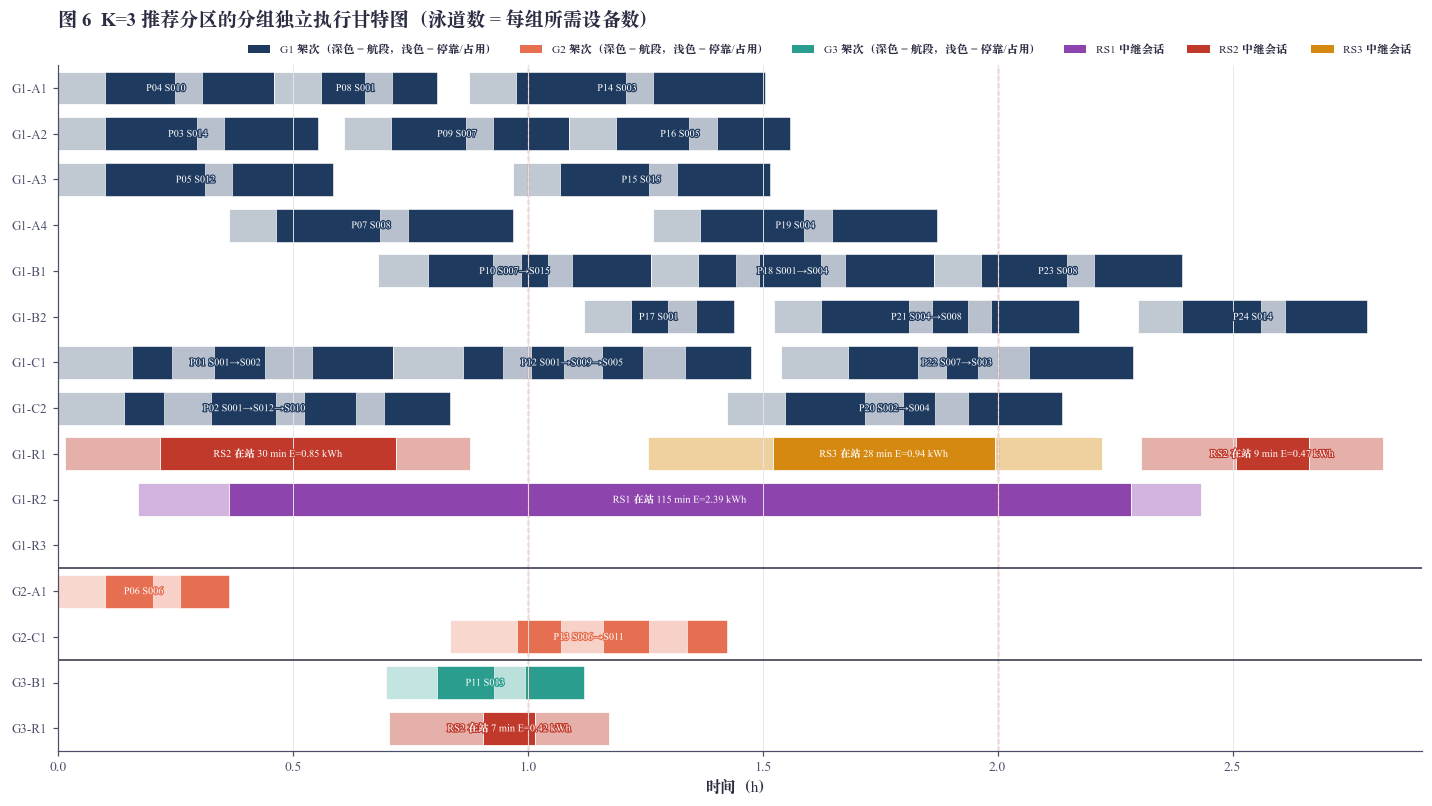

In [9]:
# 图 6：分组独立执行甘特图，泳道数等于每组资源峰值。
rows_y = []
for gi, r in enumerate(e['groups']):
    for g in TYPES:
        for lane in range(r[('UAV', g)]):
            rows_y.append((f'G{gi+1}-{g}{lane+1}', gi, 'UAV', g, lane))
    for lane in range(r['RELAY']):
        rows_y.append((f'G{gi+1}-R{lane+1}', gi, 'RELAY', None, lane))
ypos = {lab: i for i, (lab, *_rest) in enumerate(rows_y)}
fig, ax = plt.subplots(figsize=(16, max(6, 0.42*len(rows_y)+1.8)))
ax.grid(False, axis='y')
seg_by_pid = {pid: frame for pid, frame in seg.groupby('架次')}
for gi, r in enumerate(e['groups']):
    col = GROUP_COLOR[gi]
    d = plan[plan['架次'].isin(r['sorties'])]
    for row in d.itertuples(index=False):
        lane = r[('UAV', row.机型, 'lanes')][row.架次]
        y = ypos[f'G{gi+1}-{row.机型}{lane+1}']
        # 当前问题三时间分段表按航段记录；准备段和运输占用段由架次开始/起飞/返仓时刻构成。
        if row.起飞_s > row.开始_s:
            ax.add_patch(Rectangle((row.开始_s/3600, y-0.36), (row.起飞_s-row.开始_s)/3600, 0.72,
                                   facecolor=shade(col, 0.72), edgecolor='white', lw=0.5))
        # 底条表示运输占用；按问题三时间分段表覆盖各航段，停靠配送期间仍占用无人机。
        ax.add_patch(Rectangle((row.起飞_s/3600, y-0.36), (row.返仓_s-row.起飞_s)/3600, 0.72,
                               facecolor=shade(col, 0.68), edgecolor='white', lw=0.4))
        for leg in seg_by_pid.get(row.架次, seg.iloc[:0]).itertuples(index=False):
            ax.add_patch(Rectangle((leg.出发_s/3600, y-0.36), (leg.到达_s-leg.出发_s)/3600, 0.72,
                                   facecolor=col, edgecolor='white', lw=0.4))
        route = row.路线.replace('O01→', '').replace('→O01', '')
        ax.text((row.开始_s+row.返仓_s)/7200, y, f'{row.架次} {route}', ha='center', va='center',
                fontsize=6.7, color='white', path_effects=[pe.withStroke(linewidth=1.5, foreground=col)])
    for i, session in enumerate(r['sessions']):
        y = ypos[f'G{gi+1}-R{r["relay_lanes"][i]+1}']
        st_color = ST_COLOR[ST_NAMES.index(session['station']) % len(ST_COLOR)]
        ax.add_patch(Rectangle((session['t_dep']/3600, y-0.36),
                               (session['t_linked']-session['t_dep'])/3600, 0.72,
                               facecolor=shade(st_color, 0.6), edgecolor='white', lw=0.5))
        ax.add_patch(Rectangle((session['t_linked']/3600, y-0.36),
                               (session['t_leave']-session['t_linked'])/3600, 0.72,
                               facecolor=st_color, edgecolor='white', lw=0.5))
        ax.add_patch(Rectangle((session['t_leave']/3600, y-0.36),
                               (session['t_end']-session['t_leave'])/3600, 0.72,
                               facecolor=shade(st_color, 0.6), edgecolor='white', lw=0.5))
        ax.text((session['t_linked']+session['t_leave'])/7200, y,
                f'{session["station"]} 在站 {(session["t_leave"]-session["t_linked"])/60:.0f} min E={session["E"]:.2f} kWh',
                ha='center', va='center', fontsize=6.8, color='white',
                path_effects=[pe.withStroke(linewidth=1.5, foreground=st_color)])
for i, (label, gi, *_rest) in enumerate(rows_y):
    if i and rows_y[i-1][1] != gi:
        ax.axhline(i-0.5, color=PAL['ink'], lw=1.0)
ax.set_yticks(range(len(rows_y)), [row[0] for row in rows_y], fontsize=8.5)
ax.invert_yaxis()
ax.set_ylim(len(rows_y)-0.5, -0.5)
for hour in (1, 2):
    ax.axvline(hour, color=PAL['coral'], lw=0.9, ls='--', zorder=1)
ax.set_xlim(0, T_END/3600)
ax.set_xlabel('时间（h）')
handles = [Patch(facecolor=GROUP_COLOR[gi], label=f'G{gi+1} 架次（深色 = 航段，浅色 = 停靠/占用）')
           for gi in range(len(e['groups']))]
handles += [Patch(facecolor=ST_COLOR[j], label=f'{st} 中继会话') for j, st in enumerate(ST_NAMES)]
ax.legend(handles=handles, loc='lower right', bbox_to_anchor=(1.0, 1.0), ncol=6, fontsize=7.5)
ax.set_title(f'图 6  K={K_SHOW} 推荐分区的分组独立执行甘特图（泳道数 = 每组所需设备数）',
             loc='left', fontsize=12.5, pad=26)
savefig(fig, '图06_分组独立执行甘特图')

## 12 图 7：两种分区方式的比较与缺口归因

图 7 从配置规模、冗余、均衡偏差和加权缺口四个维度比较 $K=2$ 与 $K=3$，并与“不分区”的联合执行对照。缺口归因从“库存 → 联合执行需求 → 各组峰值之和”展开，说明分组造成的资源隔离增量。缺口归因表列出各组峰值时刻；这些时刻是局部峰值，不代表不同组的峰值同时发生。

,配置规模,冗余,均衡偏差,加权缺口,缺口件数,运输机A,运输机B,运输机C,电池A,电池B,电池C,中继机,能源组件
方案,,,,,,,,,,,,,
联合执行（不分区）,28,0,0.000,3,1,4,2,2,6,4,4,3,3
K=2 方案A,31,3,0.430,10,4,5,2,3,7,4,4,3,3
K=2 方案B,39,11,0.103,24,10,6,4,3,7,5,5,4,5
K=3 方案A,35,7,0.566,17,7,5,3,3,7,5,4,4,4
K=3 方案B,42,14,0.270,31,13,7,4,4,8,5,5,4,5


推荐方案的逐资源缺口归因：


,方案,资源,库存,联合峰值,分组需求,分区冗余,库存缺口,各组峰值时刻
0,K=2,运输机A,4,4,5,1,1,G1 峰值 4 @ 0.36 h；G2 峰值 1 @ 0.00 h
1,K=2,运输机C,2,2,3,1,1,G1 峰值 2 @ 0.00 h；G2 峰值 1 @ 0.84 h
2,K=2,电池A,6,6,7,1,1,G1 峰值 6 @ 0.61 h；G2 峰值 1 @ 0.00 h
3,K=2,中继机,2,3,3,0,1,G1 峰值 3 @ 2.31 h；G2 峰值 0 @ 0.00 h
4,K=3,运输机A,4,4,5,1,1,G1 峰值 4 @ 0.36 h；G2 峰值 1 @ 0.00 h；G3 峰值 0 @ 0....
5,K=3,运输机B,2,2,3,1,1,G1 峰值 2 @ 1.12 h；G2 峰值 0 @ 0.00 h；G3 峰值 1 @ 0....
6,K=3,运输机C,2,2,3,1,1,G1 峰值 2 @ 0.00 h；G2 峰值 1 @ 0.84 h；G3 峰值 0 @ 0....
7,K=3,电池A,6,6,7,1,1,G1 峰值 6 @ 0.61 h；G2 峰值 1 @ 0.00 h；G3 峰值 0 @ 0....
8,K=3,电池B,4,4,5,1,1,G1 峰值 4 @ 1.52 h；G2 峰值 0 @ 0.00 h；G3 峰值 1 @ 0....
9,K=3,中继机,2,3,4,1,2,G1 峰值 3 @ 2.31 h；G2 峰值 0 @ 0.00 h；G3 峰值 1 @ 0....


🖼️ 已保存 问题四/图07_分区比较与缺口归因.png


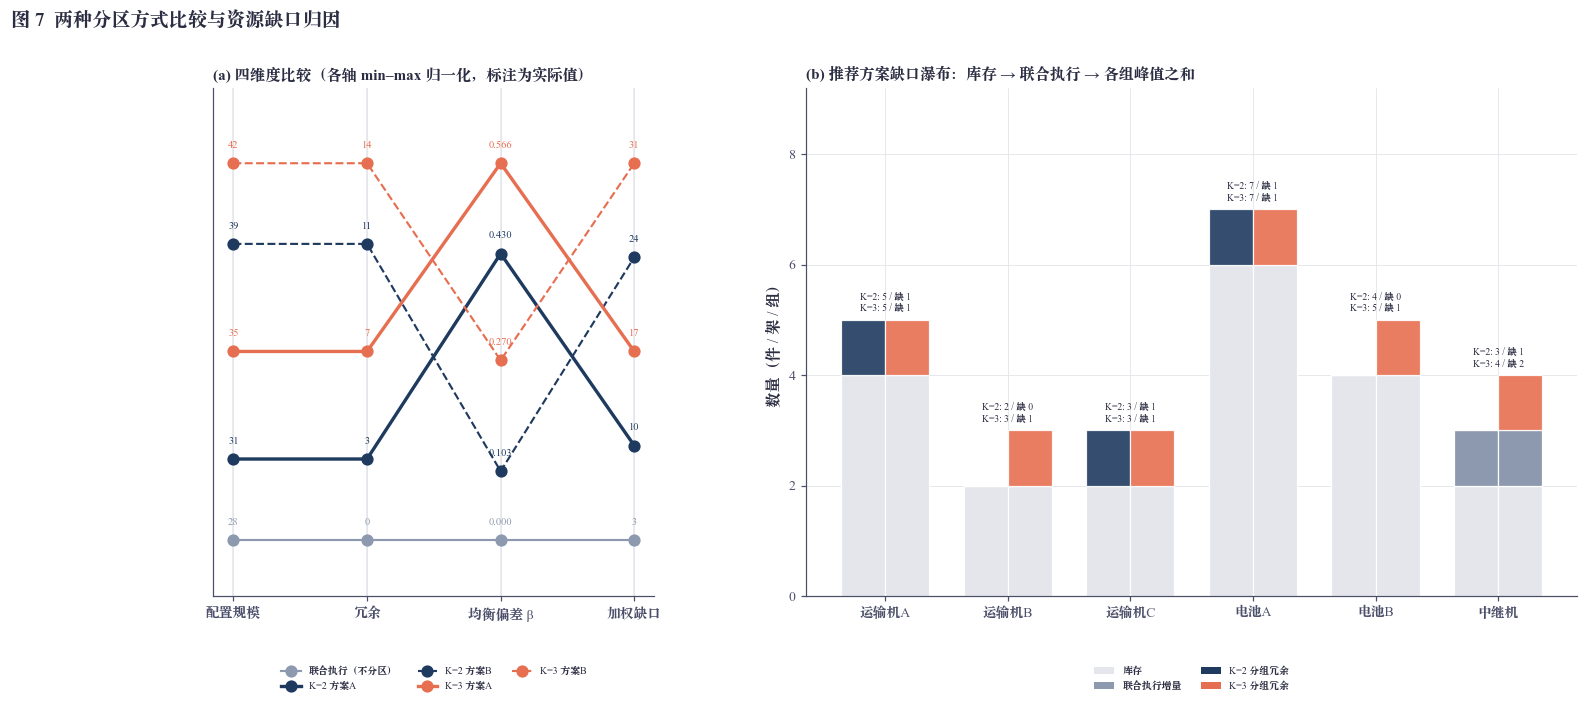

In [10]:
# 两种分区方案与联合执行基准的比较表
compare = []
for name, value in [('联合执行（不分区）', None), ('K=2 方案A', BEST[2]),
                    ('K=2 方案B', BAL[2]), ('K=3 方案A', BEST[3]), ('K=3 方案B', BAL[3])]:
    if value is None:
        row = dict(方案=name, 配置规模=sum(JOINT[k] for k in RES_KEYS), 冗余=0,
                   均衡偏差=0.0,
                   加权缺口=sum(W_GAP[k]*max(0, JOINT[k]-INV[k]) for k in RES_KEYS),
                   缺口件数=sum(max(0, JOINT[k]-INV[k]) for k in RES_KEYS))
        row.update({RES_LABEL[k]: JOINT[k] for k in RES_KEYS})
    else:
        row = dict(方案=name, 配置规模=value['scale'], 冗余=value['red_total'],
                   均衡偏差=value['beta'], 加权缺口=value['w_gap'], 缺口件数=value['n_gap'])
        row.update({RES_LABEL[k]: value['total'][k] for k in RES_KEYS})
    compare.append(row)
cmp_df = pd.DataFrame(compare).set_index('方案')
display(cmp_df.round(3))

# 推荐方案逐项缺口：拆分出联合执行缺口与组间隔离冗余。
causes = []
for K in (2, 3):
    value = BEST[K]
    for k in RES_KEYS:
        if value['gap'][k] <= 0:
            continue
        if isinstance(k, tuple):
            peak_note = '；'.join(f'G{i+1} 峰值 {r[k]} @ {r[(k[0], k[1], "peak_t")]/3600:.2f} h'
                                 for i, r in enumerate(value['groups']))
        else:
            peak_note = '；'.join(f'G{i+1} 峰值 {r[k]} @ {r[(k, "peak_t")]/3600:.2f} h'
                                 for i, r in enumerate(value['groups']))
        causes.append(dict(方案=f'K={K}', 资源=RES_LABEL[k], 库存=INV[k], 联合峰值=JOINT[k],
                           分组需求=value['total'][k], 分区冗余=value['red'][k],
                           库存缺口=value['gap'][k], 各组峰值时刻=peak_note))
cause_df = pd.DataFrame(causes)
print('推荐方案的逐资源缺口归因：')
display(cause_df)

# 图 7：四维指标比较 + 库存到联合需求、再到分组需求的缺口瀑布图。
fig = plt.figure(figsize=(16, 7.0))
gs = fig.add_gridspec(1, 2, width_ratios=[0.8, 1.4], wspace=0.25)
ax = fig.add_subplot(gs[0])
metrics = ['配置规模', '冗余', '均衡偏差', '加权缺口']
M = cmp_df[metrics].astype(float).to_numpy()
lo, hi = M.min(axis=0), M.max(axis=0)
span = np.where(hi > lo, hi-lo, 1.0)
normalized = (M-lo)/span
line_colors = [PAL['grey'], GROUP_COLOR[0], GROUP_COLOR[0], GROUP_COLOR[1], GROUP_COLOR[1]]
line_styles = ['-', '-', '--', '-', '--']
for i, (name, row) in enumerate(zip(cmp_df.index, normalized)):
    ax.plot(range(4), row, marker='o', ms=7, lw=2.2 if i in (1, 3) else 1.4,
            ls=line_styles[i], color=line_colors[i], label=name, zorder=3)
    actual = cmp_df.loc[name, metrics].to_numpy(dtype=float)
    for j, value in enumerate(actual):
        label = f'{value:.3f}' if j == 2 else f'{value:.0f}'
        ax.text(j, row[j]+0.035, label, ha='center', va='bottom', fontsize=6.8,
                color=line_colors[i])
for j in range(4):
    ax.axvline(j, color=PAL['mist'], lw=1, zorder=1)
ax.set_xticks(range(4), ['配置规模', '冗余', '均衡偏差 β', '加权缺口'], fontsize=9)
ax.set_yticks([])
ax.set_ylim(-0.15, 1.20)
ax.set_title('(a) 四维度比较（各轴 min–max 归一化，标注为实际值）', loc='left', fontsize=10)
ax.legend(fontsize=6.5, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

ax = fig.add_subplot(gs[1])
gap_keys = [k for k in RES_KEYS if BEST[2]['gap'][k] > 0 or BEST[3]['gap'][k] > 0]
if not gap_keys:
    gap_keys = RES_KEYS[:3]
x = np.arange(len(gap_keys))
width = 0.36
for K, offset in [(2, -width/2), (3, width/2)]:
    value = BEST[K]
    for i, k in enumerate(gap_keys):
        inv = INV[k]
        joint = JOINT[k]
        total = value['total'][k]
        ax.bar(x[i]+offset, inv, width=width, color=PAL['mist'], edgecolor='white', zorder=2)
        ax.bar(x[i]+offset, max(0, joint-inv), bottom=inv, width=width,
               color=PAL['grey'], edgecolor='white', zorder=3)
        ax.bar(x[i]+offset, total-max(joint, inv), bottom=max(joint, inv), width=width,
               color=GROUP_COLOR[K-2], edgecolor='white', alpha=0.9, zorder=4)
max_total = max(max(BEST[K]['total'][k] for k in gap_keys) for K in (2, 3))
for i, k in enumerate(gap_keys):
    top = max(BEST[K]['total'][k] for K in (2, 3))
    note = '\n'.join(f'K={K}: {BEST[K]["total"][k]} / 缺 {BEST[K]["gap"][k]}' for K in (2, 3))
    ax.text(x[i], top+0.12, note, ha='center', va='bottom', fontsize=6.3, color=PAL['ink'])
ax.set_ylim(0, max_total + 2.2)
ax.set_xticks(x, [RES_LABEL[k] for k in gap_keys])
ax.set_ylabel('数量（件 / 架 / 组）')
ax.set_title('(b) 推荐方案缺口瀑布：库存 → 联合执行 → 各组峰值之和', loc='left', fontsize=10)
ax.legend(handles=[Rectangle((0, 0), 1, 1, facecolor=PAL['mist'], label='库存'),
                   Rectangle((0, 0), 1, 1, facecolor=PAL['grey'], label='联合执行增量'),
                   Patch(facecolor=GROUP_COLOR[0], label='K=2 分组冗余'),
                   Patch(facecolor=GROUP_COLOR[1], label='K=3 分组冗余')],
          loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=6.5)
fig.suptitle('图 7  两种分区方式比较与资源缺口归因', x=0.01, ha='left',
             fontsize=12.5, fontweight='bold')
fig.subplots_adjust(bottom=0.22, top=0.88)
savefig(fig, '图07_分区比较与缺口归因')

## 13 附加分析：允许组内平移架次开始时刻，缺口能消解多少（图 8）

正式分区结果保持问题三的固定时序。附加分析保持每个架次的路线、组批、持续时间和逐箱相对送达偏移不变，只在组内按硬时限最迟开始时刻排序，并使用可用运输机与满电电池列表调度。每组完成时间最多比固定时序晚 30 min；架次平移后同步平移通信需求，再按相同规则重建中继会话。逐类减少资源，得到经过核验的可行配置；这是该调度规则找到的可行值，不证明所有平移方案中的严格最小值。图 8 比较固定时序需求、平移后可行需求与库存。

K=2 各组平移后可行配置：


,固定完成_h,平移完成_h,运输机A 固定,运输机B 固定,运输机C 固定,电池A 固定,电池B 固定,电池C 固定,中继机 固定,能源组件 固定,运输机A 平移,运输机B 平移,运输机C 平移,电池A 平移,电池B 平移,电池C 平移,中继机 平移,能源组件 平移
任务组,,,,,,,,,,,,,,,,,,
G1,2.82,2.37,4,2,2,6,4,3,3,3,3,2,2,4,3,3,3,3
G2,1.42,0.59,1,0,1,1,0,1,0,0,1,0,1,1,0,1,0,0


库存缺口：固定时序 {'运输机A': 1, '运输机C': 1, '电池A': 1, '中继机': 1} → 平移后可行上界 {'运输机C': 1, '中继机': 1}
K=3 各组平移后可行配置：


,固定完成_h,平移完成_h,运输机A 固定,运输机B 固定,运输机C 固定,电池A 固定,电池B 固定,电池C 固定,中继机 固定,能源组件 固定,运输机A 平移,运输机B 平移,运输机C 平移,电池A 平移,电池B 平移,电池C 平移,中继机 平移,能源组件 平移
任务组,,,,,,,,,,,,,,,,,,
G1,2.82,3.20,4,2,2,6,4,3,3,3,2,1,2,4,3,3,3,3
G2,1.42,0.59,1,0,1,1,0,1,0,0,1,0,1,1,0,1,0,0
G3,1.17,0.47,0,1,0,0,1,0,1,1,0,1,0,0,1,0,1,1


库存缺口：固定时序 {'运输机A': 1, '运输机B': 1, '运输机C': 1, '电池A': 1, '电池B': 1, '中继机': 2} → 平移后可行上界 {'运输机C': 1, '中继机': 2}


🖼️ 已保存 问题四/图08_平移调度消解缺口.png


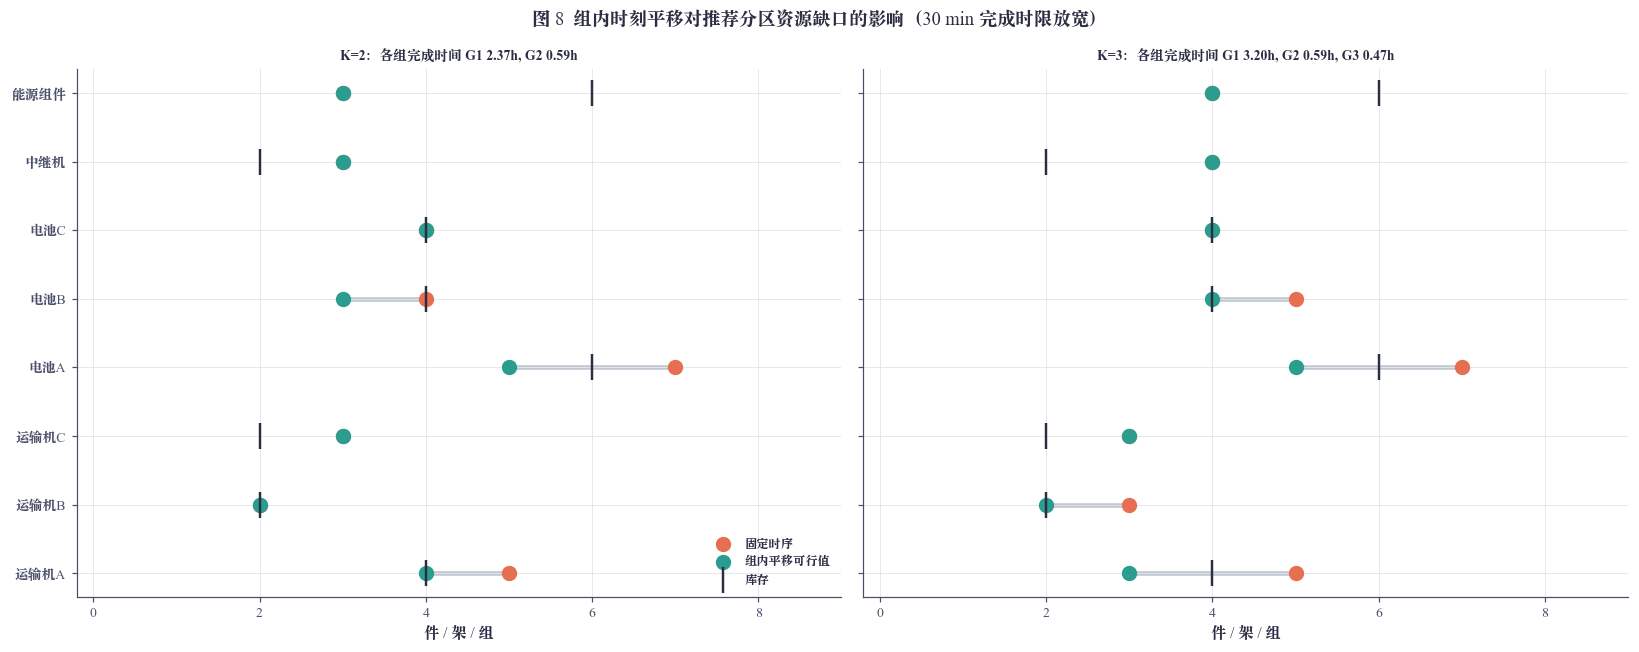

In [11]:
# 排序与释放：通信接入必须在进入盲区前完成。
plan_by_id=plan.set_index('架次')
box_by_pid={pid:d for pid,d in box_df.groupby('架次')}
demand_by_pid={pid:d for pid,d in dem_iv.groupby('架次')}
def latest_start(pid):
    d=box_by_pid[pid].dropna(subset=['硬时限_s'])
    if d.empty:return float('inf')
    original=float(plan_by_id.loc[pid,'开始_s'])
    return float((d['硬时限_s']-(d['送达_s']-original)).min())
def earliest_start(pid):
    if pid not in demand_by_pid:return 0.
    d=demand_by_pid[pid];original=float(plan_by_id.loc[pid,'开始_s'])
    return max(0.,max(R['t_prep']+ST[st]['tgo']+R['t_link']-(a-original)
                      for a,st in zip(d['开始_s'],d['中继站'])))
LST={p:latest_start(p) for p in plan['架次']}
EST={p:earliest_start(p) for p in plan['架次']}

def reschedule_group(r,cfg):
    sub=plan[plan['架次'].isin(r['sorties'])]
    # 两种确定性顺序；资源列表调度可提前到 t=0，绝不推迟硬时限。
    orders=[sub.sort_values(['开始_s','架次'])['架次'].tolist(),
            sorted(sub['架次'],key=lambda p:(LST[p],float(plan_by_id.loc[p,'开始_s']),p))]
    best=None
    for order in orders:
        u={g:[0.]*cfg[('UAV',g)] for g in TYPES};b={g:[0.]*cfg[('BAT',g)] for g in TYPES}
        starts={};rows=[];valid=True
        for pid in order:
            v=plan_by_id.loc[pid];g=v['机型']
            if not u[g] or not b[g]:valid=False;break
            i=min(range(len(u[g])),key=lambda i:u[g][i]);j=min(range(len(b[g])),key=lambda j:b[g][j])
            st=max(u[g][i],b[g][j],EST[pid]);en=st+float(v['持续_s'])
            if st>LST[pid]+1e-7:valid=False;break
            u[g][i]=en;b[g][j]=en+float(v['充电_s'])
            starts[pid]=st;rows.append((pid,g,i,j,st,en,b[g][j]))
        if not valid:continue
        dv=dem_iv[dem_iv['架次'].isin(starts)].copy()
        dv['shift_s']=dv['架次'].map(starts)-dv['架次'].map(plan_by_id['开始_s'])
        dv['开始_s']+=dv['shift_s'];dv['结束_s']+=dv['shift_s']
        try:sessions=build_sessions(dv) if len(dv) else []
        except ValueError:continue
        nr=max_overlap((x['t_dep'],x['t_end']+R['t_turn']) for x in sessions)[0]
        nc=max_overlap((x['t_dep'],x['t_end']+t_chg(x['soc'],T_FULL_R)) for x in sessions)[0]
        mk=max([v[5] for v in rows]+[x['t_end'] for x in sessions]+[0.])
        if mk>r['makespan']+1800+1e-7 or nr>r['RELAY'] or nc>r['COMP']:continue
        cand=dict(starts=starts,rows=rows,sessions=sessions,makespan=mk,relay=nr,comp=nc)
        if best is None or (mk,nr,nc)<(best['makespan'],best['relay'],best['comp']):best=cand
    return best

def reduce_config(r):
    cfg={k:r[k] for k in RES_KEYS}
    current=reschedule_group(r,cfg)
    if current is None:raise RuntimeError('固定配置在平移列表调度下不可行')
    changed=True
    while changed:
        changed=False
        for key in [('UAV',g) for g in TYPES]+[('BAT',g) for g in TYPES]:
            if cfg[key]==0:continue
            trial={**cfg,key:cfg[key]-1}
            cand=reschedule_group(r,trial)
            if cand is not None:cfg=trial;current=cand;changed=True
    # 后续重新建链得到的中继/组件峰值，是此可行时序的实际需求。
    cfg['RELAY']=current['relay'];cfg['COMP']=current['comp']
    return cfg,current
SHIFT={}
for K in (2,3):
    rows=[]
    for gi,r in enumerate(BEST[K]['groups']):
        cfg,sol=reduce_config(r);SHIFT[K,gi]=(cfg,sol)
        rows.append({'任务组':f'G{gi+1}','固定完成_h':r['makespan']/3600,'平移完成_h':sol['makespan']/3600,
                     **{f'{RES_LABEL[k]} 固定':r[k] for k in RES_KEYS},
                     **{f'{RES_LABEL[k]} 平移':cfg[k] for k in RES_KEYS}})
    print(f'K={K} 各组平移后可行配置：');display(pd.DataFrame(rows).set_index('任务组').round(2))
    old=BEST[K]['total'];new={k:sum(SHIFT[K,i][0][k] for i in range(K)) for k in RES_KEYS}
    print('库存缺口：固定时序', {RES_LABEL[k]:old[k]-INV[k] for k in RES_KEYS if old[k]>INV[k]},
          '→ 平移后可行上界', {RES_LABEL[k]:new[k]-INV[k] for k in RES_KEYS if new[k]>INV[k]})

# 图 8：固定时序资源需求、组内平移后的可行需求与库存。
fig,axes=plt.subplots(1,2,figsize=(15,6),sharey=True)
for ax,K in zip(axes,(2,3)):
    y=np.arange(len(RES_KEYS));fixed=np.array([BEST[K]['total'][k] for k in RES_KEYS])
    shifted=np.array([sum(SHIFT[K,i][0][k] for i in range(K)) for k in RES_KEYS]);inv=np.array([INV[k] for k in RES_KEYS])
    for yi in y:ax.plot([shifted[yi],fixed[yi]],[yi,yi],color=PAL['grey'],lw=3,alpha=.55,zorder=1)
    ax.scatter(fixed,y,color=PAL['coral'],s=85,label='固定时序',zorder=3)
    ax.scatter(shifted,y,color=PAL['teal'],s=85,label='组内平移可行值',zorder=4)
    ax.scatter(inv,y,color=PAL['ink'],marker='|',s=280,label='库存',zorder=5)
    ax.set_yticks(y,[RES_LABEL[k] for k in RES_KEYS]);ax.invert_yaxis()
    ax.set_xlim(-.2,max(fixed.max(),shifted.max(),inv.max())+2);ax.set_xlabel('件 / 架 / 组')
    ax.set_title(f'K={K}：各组完成时间 '+', '.join(f'G{i+1} {SHIFT[K,i][1]["makespan"]/3600:.2f}h' for i in range(K)),fontsize=9)
axes[0].legend(loc='lower right',fontsize=8)
fig.suptitle('图 8  组内时刻平移对推荐分区资源缺口的影响（30 min 完成时限放宽）')
fig.tight_layout();savefig(fig,'图08_平移调度消解缺口')

## 14 结果导出与结论摘要

最终核对服务区覆盖、架次归组、多点架次不可拆分、资源泳道峰值、中继需求覆盖与能量返航约束，以及平移后的硬时限和 30 min 完成时间限制。下方导出全部划分、推荐配置、比较、缺口归因和核验结果，并汇总两种分区的主要缺口。结论仅适用于本 Notebook 读取的问题三方案及固定时序核算口径。

In [12]:
checks = []
def check(name, ok, detail=''):
    checks.append(dict(检查项=name, 通过=bool(ok), 说明=detail))
for K in (2, 3):
    value = BEST[K]
    all_areas = [a for r in value['groups'] for a in r['areas']]
    all_pids = [pid for r in value['groups'] for pid in r['sorties']]
    check(f'K={K} 每个服务区仅一组', Counter(all_areas) == Counter(AREA_IDS))
    check(f'K={K} 每个架次仅一组', Counter(all_pids) == Counter(plan['架次']))
    check(f'K={K} 多点架次不拆分', all(
        set(ar).issubset(set(next(r['areas'] for r in value['groups'] if ar[0] in r['areas'])))
        for ar in plan['areas']))
    check(f'K={K} 资源泳道数等于峰值', all(
        len(set(r[('UAV', g, 'lanes')].values())) == r[('UAV', g)] and
        len(set(r[('BAT', g, 'lanes')].values())) == r[('BAT', g)]
        for r in value['groups'] for g in TYPES))
    covered = True
    for gi, r in enumerate(value['groups']):
        d = dem_iv[dem_iv['架次'].isin(r['sorties'])]
        for w in d.itertuples(index=False):
            spans = sorted((x['t_linked'], x['t_leave']) for x in r['sessions']
                           if x['station'] == w.中继站)
            pos = float(w.开始_s)
            for a, b in spans:
                if a <= pos + 1e-7:
                    pos = max(pos, b)
                if pos >= float(w.结束_s)-1e-7:
                    break
            covered &= pos >= float(w.结束_s)-1e-7
    energy = all(x['E'] <= R['budget']+1e-7 and x['soc'] >= R['rho']-1e-7
                 for r in value['groups'] for x in r['sessions'])
    check(f'K={K} 中继需求区间全覆盖', covered, f'{len(dem_iv)} 个需求窗按组分配')
    check(f'K={K} 中继能量与返航余量', energy)
    for gi, r in enumerate(value['groups']):
        cfg, sol = SHIFT[K, gi]
        shifted_boxes = box_df[box_df['架次'].isin(sol['starts'])].copy()
        shifted_boxes['送达_平移_s'] = (
            shifted_boxes['送达_s'] + shifted_boxes['架次'].map(sol['starts']) -
            shifted_boxes['架次'].map(plan_by_id['开始_s']))
        hard = shifted_boxes.dropna(subset=['硬时限_s'])
        deadlines_ok = bool((hard['送达_平移_s'] <= hard['硬时限_s']+1e-7).all())
        check(f'K={K} G{gi+1} 平移后硬时限', deadlines_ok, f'{len(hard)} 箱')
        check(f'K={K} G{gi+1} 完成时间限制', sol['makespan'] <= r['makespan']+1800+1e-7)
        check(f'K={K} G{gi+1} 平移后中继资源',
              sol['relay'] <= r['RELAY'] and sol['comp'] <= r['COMP'])
VER = pd.DataFrame(checks)
display(VER)
print('核对结果：', '全部通过' if VER['通过'].all() else '存在未通过项，请查看上表')

# 导出分区、配置、对比、归因、时移可行值与核验结果；不改写问题三原始结果表。
RESULT_DIR = CODE / '问题四'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
xlsx_path = RESULT_DIR / '问题四结果.xlsx'
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    unit_df.to_excel(writer, sheet_name='1_原子执行单元', index=False)
    rank_table(PART[2]).to_excel(writer, sheet_name='2_K2全部划分', index=False)
    rank_table(PART[3]).to_excel(writer, sheet_name='3_K3全部划分', index=False)
    for (K, tag), table in CFG.items():
        table.round(3).to_excel(writer, sheet_name=f'4_K{K}方案{tag}配置')
    cmp_df.round(3).to_excel(writer, sheet_name='5_分区对比')
    cause_df.to_excel(writer, sheet_name='6_缺口归因', index=False)
    VER.to_excel(writer, sheet_name='7_可行性核对', index=False)
    shift_rows = []
    for K in (2, 3):
        for gi in range(K):
            cfg, sol = SHIFT[K, gi]
            shift_rows.append(dict(K=K, 任务组=f'G{gi+1}',
                                   平移后完成_h=sol['makespan']/3600,
                                   **{RES_LABEL[k]: cfg[k] for k in RES_KEYS}))
    pd.DataFrame(shift_rows).to_excel(writer, sheet_name='8_平移后可行配置', index=False)
print(f'结果已写入：{xlsx_path.relative_to(PROJECT)}')

print('\n' + '='*72 + '\n问题四结论摘要\n' + '='*72)
print(f'1）任务耦合：{int(plan["停靠点"].gt(1).sum())} 个多点架次把 {len(AREA_IDS)} 个服务区连成 {len(UNITS)} 个原子单元，最大单元含 {len(UNITS[0])} 个服务区。')
print(f'2）精确枚举：K=2 有 {len(PART[2])} 种划分，K=3 有 {len(PART[3])} 种划分。')
for K in (2, 3):
    value = BEST[K]
    shortage = {RES_LABEL[k]: value['gap'][k] for k in RES_KEYS if value['gap'][k] > 0}
    shifted = {k: sum(SHIFT[K, gi][0][k] for gi in range(K)) for k in RES_KEYS}
    feasible_gap = {RES_LABEL[k]: max(0, shifted[k]-INV[k]) for k in RES_KEYS
                    if shifted[k] > INV[k]}
    print(f'3）K={K} 推荐 {pname(value)}；配置规模 {value["scale"]}，冗余 {value["red_total"]}，工作量偏差 β={value["beta"]:.3f}，加权缺口 {value["w_gap"]}。')
    print('   固定时序缺口：', shortage)
    print('   组内平移后可行配置缺口：', feasible_gap)

,检查项,通过,说明
0,K=2 每个服务区仅一组,True,
1,K=2 每个架次仅一组,True,
2,K=2 多点架次不拆分,True,
3,K=2 资源泳道数等于峰值,True,
4,K=2 中继需求区间全覆盖,True,75 个需求窗按组分配
5,K=2 中继能量与返航余量,True,
6,K=2 G1 平移后硬时限,True,27 箱
7,K=2 G1 完成时间限制,True,
8,K=2 G1 平移后中继资源,True,
9,K=2 G2 平移后硬时限,True,4 箱


核对结果： 全部通过
结果已写入：26-Modeling/002-Code/问题四/问题四结果.xlsx

问题四结论摘要
1）任务耦合：9 个多点架次把 15 个服务区连成 5 个原子单元，最大单元含 8 个服务区。
2）精确枚举：K=2 有 15 种划分，K=3 有 25 种划分。
3）K=2 推荐 {U1,U2,U4,U5} | {U3}；配置规模 31，冗余 3，工作量偏差 β=0.430，加权缺口 10。
   固定时序缺口： {'运输机A': 1, '运输机C': 1, '电池A': 1, '中继机': 1}
   组内平移后可行配置缺口： {'运输机C': 1, '中继机': 1}
3）K=3 推荐 {U1,U2,U5} | {U3} | {U4}；配置规模 35，冗余 7，工作量偏差 β=0.566，加权缺口 17。
   固定时序缺口： {'运输机A': 1, '运输机B': 1, '运输机C': 1, '电池A': 1, '电池B': 1, '中继机': 2}
   组内平移后可行配置缺口： {'运输机C': 1, '中继机': 2}
